In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.distributions import bernoulli, uniform
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import Counter
from tqdm import tqdm
from tqdm.notebook import tqdm
import math
import random
import os
from pathlib import Path
from PIL import Image
import pytesseract
import xml.etree.ElementTree as ET
from IPython.display import Image
%matplotlib inline
import io
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

# Data Loading and Preprocessing

In [7]:
def parse_xml_strokes(xml_file):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        strokes = []
        for stroke in root.findall(".//Stroke"):
            points = []
            for point in stroke.findall("Point"):
                x = float(point.attrib['x'])
                y = float(point.attrib['y'])
                points.append([x, y])
            
            points = np.array(points)
            
            # Calculate relative coordinates (deltas)
            deltas = np.zeros_like(points)
            deltas[1:] = points[1:] - points[:-1]
            
            # Create stroke array: [pen_state, delta_x, delta_y]
            stroke_data = np.zeros((len(points), 3))
            stroke_data[:, 1] = deltas[:, 0]  # delta_x
            stroke_data[:, 2] = deltas[:, 1]  # delta_y
            stroke_data[0, 0] = 1  # Pen up at the start of each stroke
            
            strokes.append(stroke_data)
        
        if not strokes:
            return None
        
        sequence = []
        for i, stroke in enumerate(strokes):
            sequence.append(stroke)
            # Add pen-up state between strokes (except for the last one)
            if i < len(strokes) - 1:
                sequence.append(np.array([[1, 0, 0]]))
        
        return np.vstack(sequence)
    except ET.ParseError:
        print(f"Warning: Failed to parse XML file {xml_file}. Skipping.")
        return None
    except ValueError as e:
        print(f"Warning: Invalid data in {xml_file}: {e}. Skipping.")
        return None

def process_iam_dataset(line_strokes_dir, ascii_dir, output_npy="strokes.npy", output_txt="sentences.txt", max_sequences=6000):
    if os.path.exists(output_npy):
        print(f"{output_npy} already exists. Skipping preprocessing.")
        return
    
    all_xml_paths = []
    for root, _, files in os.walk(line_strokes_dir):
        for file in files:
            if file.endswith(".xml"):
                all_xml_paths.append(os.path.join(root, file))
    
    if len(all_xml_paths) < max_sequences:
        raise ValueError(f"Not enough XML files: {len(all_xml_paths)} < {max_sequences}")
    
    random.shuffle(all_xml_paths)
    
    strokes_list = []
    sentences = []
    
    for xml_path in all_xml_paths:
        if len(strokes_list) >= max_sequences:
            break
        
        rel_path = os.path.relpath(xml_path, line_strokes_dir)
        dir_name, file_name = os.path.split(rel_path)
        base_name, _ = os.path.splitext(file_name) 
        parts = base_name.split('-')  
        
        if len(parts) < 2:
            print(f"Warning: Invalid XML file name {file_name}. Skipping.")
            continue
        
        form_id = '-'.join(parts[:-1])  
        line_number_str = parts[-1] 
        
        try:
            line_idx = int(line_number_str) - 1  
        except ValueError:
            print(f"Warning: Invalid line number {line_number_str} in {file_name}. Skipping.")
            continue
        
        ascii_rel_dir = dir_name 
        ascii_file = form_id + ".txt" 
        ascii_rel_path = os.path.join(ascii_rel_dir, ascii_file)
        ascii_path = os.path.join(ascii_dir, ascii_rel_path)
        
        if not os.path.exists(ascii_path):
            print(f"Warning: ASCII file {ascii_path} does not exist. Skipping {xml_path}.")
            continue
        
        try:
            with open(ascii_path, 'r') as f:
                lines = f.readlines()
        except IOError:
            print(f"Warning: Failed to read ASCII file {ascii_path}. Skipping.")
            continue
        
        csr_start = False
        csr_lines = []
        for line in lines:
            line = line.strip()
            if line == "CSR:":
                csr_start = True
                continue
            if csr_start and line:
                csr_lines.append(line)
        
        if line_idx < 0 or line_idx >= len(csr_lines):
            print(f"Warning: line_idx {line_idx} out of range for {ascii_path}, total csr_lines: {len(csr_lines)}. Skipping.")
            continue
        
        sentence = csr_lines[line_idx]
        
        stroke_data = parse_xml_strokes(xml_path)
        
        if stroke_data is None or len(stroke_data) == 0:
            print(f"Warning: No valid strokes in {xml_path}. Skipping.")
            continue
        
        strokes_list.append(stroke_data)
        sentences.append(sentence)
    
    if len(strokes_list) < max_sequences:
        raise ValueError(f"Only {len(strokes_list)} valid sequences collected, less than {max_sequences} requested.")
    
    strokes_array = np.array(strokes_list, dtype=object)
    
    np.save(output_npy, strokes_array)
    print(f"Saved {output_npy} with {len(strokes_array)} sequences.")
    
    with open(output_txt, 'w') as f:
        for sentence in sentences:
            f.write(sentence + "\n")
    print(f"Saved {output_txt} with {len(sentences)} sentences.")

line_strokes_dir = "data/lineStrokes"
ascii_dir = "data/ascii"
output_npy = "data/strokes.npy"
output_txt = "data/sentences.txt"

process_iam_dataset(line_strokes_dir, ascii_dir, output_npy, output_txt)

data/strokes.npy already exists. Skipping preprocessing.


in the abundance of peace"


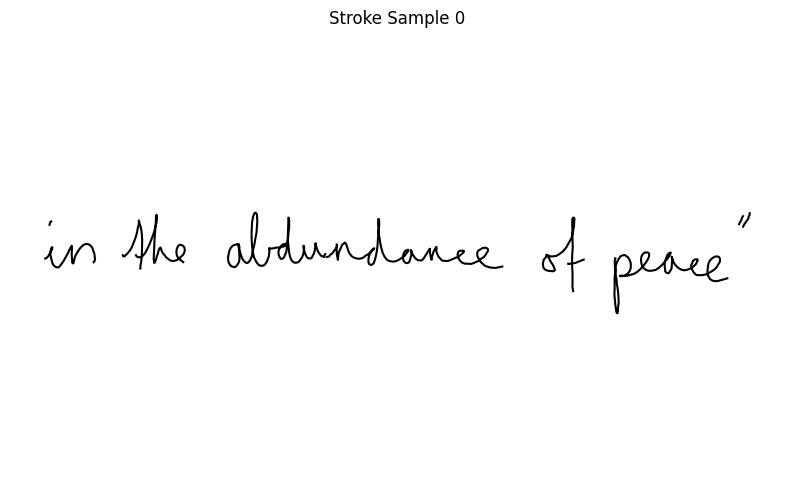

In [8]:
def plot_original_strokes_fixed(stroke, title="Handwriting Sample", save_path=None):

    stroke = np.array(stroke)
    
    if stroke.shape[1] != 3:
        raise ValueError(f"Expected stroke shape (T, 3), got {stroke.shape}")
    
    pen_state = stroke[:, 0]
    delta_x = stroke[:, 1]
    delta_y = stroke[:, 2]
    
    x = np.cumsum(delta_x)
    y = np.cumsum(delta_y)
    
    # Flip both x and y to rotate 180 degrees (upside down)
    x = x  
    y = y  
    
    plt.figure(figsize=(10, 6))
    
    i = 0
    while i < len(stroke):
        if pen_state[i] == 0:
            stroke_x = [x[i]]
            stroke_y = [y[i]]
            j = i + 1
            while j < len(stroke) and pen_state[j] == 0:
                stroke_x.append(x[j])
                stroke_y.append(y[j])
                j += 1
            plt.plot(stroke_x, stroke_y, 'k-', linewidth=1.5)
            i = j
        else:
            i += 1

    plt.axis('equal')
    plt.title(title)
    plt.axis('off')

    plt.show()
    plt.close()

strokes = np.load("data/strokes.npy", allow_pickle=True, encoding='bytes')
with open("data/sentences.txt", "r") as file:
    first_line = file.readline().strip() 
    print(first_line)
sample_idx = 0
plot_original_strokes_fixed(strokes[sample_idx], title=f"Stroke Sample {sample_idx}")

In [9]:
class Global:
    train_mean = 0.0
    train_std = 1.0
import numpy as np
from collections import Counter


def train_offset_normalization(data):
    mean = data[:, :, 1:].mean(axis=(0, 1))
    data[:, :, 1:] -= mean
    std = data[:, :, 1:].std(axis=(0, 1))
    data[:, :, 1:] /= std

    return mean, std, data


def valid_offset_normalization(mean, std, data):
    data[:, :, 1:] -= mean
    data[:, :, 1:] /= std
    return data


def data_denormalization(mean, std, data):
    data[:, :, 1:] *= std
    data[:, :, 1:] += mean

    return data


def data_normalization(data):
    mean = data[:, 1:].mean(axis=0)
    data[:, 1:] -= mean
    std = data[:, 1:].std(axis=0)
    data[:, 1:] /= std

    return mean, std, data


def data_processing(data):
    min_xy = data[:, 1:].min(axis=0)
    data[:, 1:] -= min_xy
    max_xy = data[:, 1:].max(axis=0)
    data[:, 1:] /= (max_xy - min_xy)
    data[:, 1:] *= 10
    return data


In [10]:
class HandwritingDataset(Dataset):

    def __init__(self, data_path, split='train', text_req=False, debug=False, max_seq_len=300, data_aug=False):

        self.text_req = text_req
        self.max_seq_len = max_seq_len
        self.data_aug = data_aug

        strokes = np.load(data_path + 'strokes.npy', allow_pickle=True, encoding='bytes')
        with open(data_path + 'sentences.txt') as file:
            texts = file.read().splitlines()

        lengths = [len(stroke) for stroke in strokes]
        max_len = np.max(lengths)
        n_total = len(strokes)

        mask_shape = (n_total, max_len)
        mask = np.zeros(mask_shape, dtype=np.float32)

        char_seqs = [list(char_seq) for char_seq in texts]
        char_seqs = np.array(char_seqs, dtype=object)

        char_lens = [len(char_seq) for char_seq in char_seqs]
        max_char_len = np.max(char_lens)

        mask_shape = (n_total, max_char_len)  # (6000,64)
        char_mask = np.zeros(mask_shape, dtype=np.float32)

        inp_text = np.ndarray((n_total, max_char_len), dtype='<U1')
        inp_text[:, :] = ' '

        data_shape = (n_total, max_len, 3)
        data = np.zeros(data_shape, dtype=np.float32)

        for i, (seq_len, text_len) in enumerate(zip(lengths, char_lens)):
            mask[i, :seq_len] = 1.
            data[i, :seq_len] = strokes[i]
            char_mask[i, :text_len] = 1.
            inp_text[i, :text_len] = char_seqs[i]

        self.id_to_char, self.char_to_id = self.build_vocab(inp_text)
        self.vocab_size = len(self.id_to_char)

        idx_permute = np.random.permutation(n_total)
        data = data[idx_permute]
        mask = mask[idx_permute]
        inp_text = inp_text[idx_permute]
        char_mask = char_mask[idx_permute]

        if debug:
            data = data[:64]
            mask = mask[:64]
            inp_text = inp_text[:64]
            char_mask = char_mask[:64]

        n_train = int(0.9 * data.shape[0])
        self._data = data
        if split == 'train':
            self.dataset = data[:n_train]
            self.mask = mask[:n_train]
            self.texts = inp_text[:n_train]
            self.char_mask = char_mask[:n_train]
            Global.train_mean, Global.train_std, self.dataset = train_offset_normalization(
                self.dataset)

        elif split == 'valid':
            self.dataset = data[n_train:]
            self.mask = mask[n_train:]
            self.texts = inp_text[n_train:]
            self.char_mask = char_mask[n_train:]
            self.dataset = valid_offset_normalization(
                Global.train_mean, Global.train_std, self.dataset)

    def __len__(self):
        return self.dataset.shape[0]

    def idx_to_char(self, id_seq):
        return np.array([self.id_to_char[id] for id in id_seq])

    def char_to_idx(self, char_seq):
        return np.array([self.char_to_id[char] for char in char_seq]).astype(np.float32)

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(text)
        unique_char = sorted(counter)
        vocab_size = len(unique_char)

        id_to_char = dict(zip(np.arange(vocab_size), unique_char))
        char_to_id = dict([(v, k) for (k, v) in id_to_char.items()])
        return id_to_char, char_to_id

    def __getitem__(self, idx):

        mask = torch.from_numpy(self.mask[idx])

        if self.text_req:
            input_seq = torch.zeros(self.dataset[idx].shape, dtype=torch.float32)
            input_seq[1:, :] = torch.from_numpy(self.dataset[idx, :-1, :])

            target = torch.from_numpy(self.dataset[idx])
            text = torch.from_numpy(self.char_to_idx(self.texts[idx]))
            char_mask = torch.from_numpy(self.char_mask[idx])
            return (input_seq, target, mask, text, char_mask)
        elif self.data_aug:
            seq_len = len(mask.nonzero())
            start = 0
            end = self.max_seq_len

            if seq_len > self.max_seq_len:
                start = np.random.randint(0, high=seq_len - self.max_seq_len)
                end = start + self.max_seq_len

            stroke = self.dataset[idx, start:end, :]

            input_seq = torch.zeros(stroke.shape, dtype=torch.float32)
            input_seq[1:, :] = torch.from_numpy(stroke[:-1, :])

            target = torch.from_numpy(stroke)
            mask = mask[start:end]

            return (input_seq, target, mask)
        else:
            input_seq = torch.zeros(self.dataset[idx].shape, dtype=torch.float32)
            input_seq[1:, :] = torch.from_numpy(self.dataset[idx, :-1, :])
            target = torch.from_numpy(self.dataset[idx])
            return (input_seq, target, mask)


In [11]:
def plot_stroke(stroke, save_name=None, display=True):
    f, ax = plt.subplots()
    x = np.cumsum(stroke[:, 1])
    y = np.cumsum(stroke[:, 2])
    size_x = x.max() - x.min() + 1.0
    size_y = y.max() - y.min() + 1.0
    f.set_size_inches(5.0 * size_x / size_y, 5.0)
    cuts = np.where(stroke[:, 0] == 1)[0]
    start = 0
    for cut_value in cuts:
        ax.plot(x[start:cut_value], y[start:cut_value], "k-", linewidth=3)
        start = cut_value + 1
    ax.axis("off")
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

    if display:
        plt.show()

    if save_name:
        try:
            plt.savefig(save_name, bbox_inches="tight", pad_inches=0.5)
            print(f"Saved plot to {save_name}")
        except Exception as e:
            print(f"Error saving image to {save_name}: {e}")

    plt.close()

In [12]:
data_path = '../data/'
traindata = HandwritingDataset(data_path, split='train', text_req=False, debug=False)
validdata = HandwritingDataset(data_path, split='valid', text_req=False, debug=False)
print('Size of train dataset: {}'.format(len(traindata)))
print('Size of valid dataset: {}'.format(len(validdata)))
print('Shape of train dataset: {}'.format(traindata.dataset.shape))

Size of train dataset: 5400
Size of valid dataset: 600
Shape of train dataset: (5400, 1191, 3)


torch.Size([1191, 3])
cpu
Normalized data


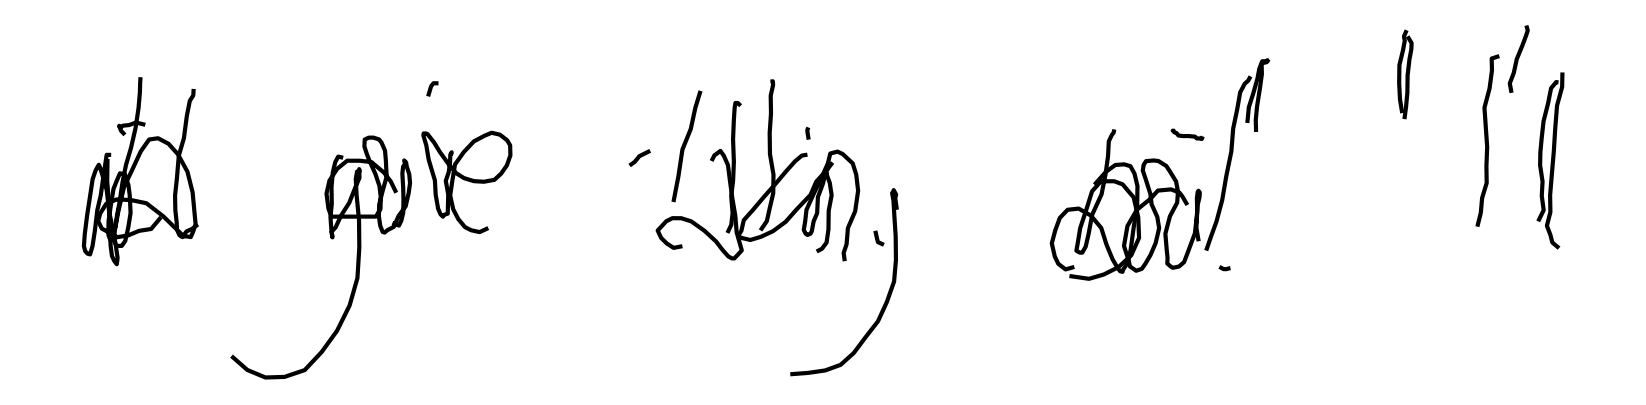

In [13]:
idx = 0
input_seq, target, mask = traindata[idx]
print(input_seq.shape)
print(input_seq.device)
print('Normalized data')
plot_stroke(input_seq.numpy())

(1, 1191, 3)
Train mean: [ 0.22335576 -0.00330548] 
 Train std: [1.5324677 1.3639469]
Denormalized data


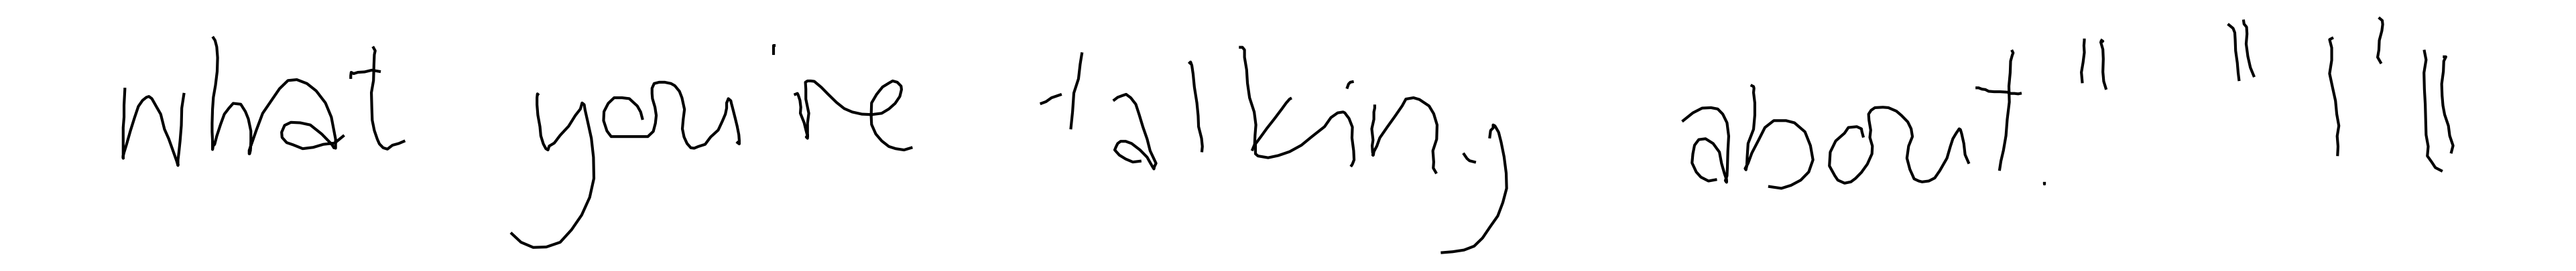

In [14]:
stroke = input_seq.unsqueeze(0).numpy()
print(stroke.shape)
print('Train mean: {} \n Train std: {}'.format(Global.train_mean, Global.train_std))
denor_stroke_seq = data_denormalization(Global.train_mean, Global.train_std, stroke)
print('Denormalized data')
plot_stroke(denor_stroke_seq[0])

# Model Training

In [15]:
def stable_softmax(X, dim=2):
    max_vec = torch.max(X, dim, keepdim=True)
    exp_X = torch.exp(X - max_vec[0])
    sum_exp_X = torch.sum(exp_X, dim, keepdim=True)
    X_hat = exp_X / sum_exp_X
    return X_hat


def compute_nll_loss(targets, y_hat, mask, M=20):
    epsilon = 1e-6
    split_sizes = [1] + [20] * 6
    y = torch.split(y_hat, split_sizes, dim=2)

    eos_logit = y[0].squeeze()
    log_mixture_weights = F.log_softmax(y[1], dim=2)

    mu_1 = y[2]
    mu_2 = y[3]

    logstd_1 = y[4]
    logstd_2 = y[5]

    rho = torch.tanh(y[6])

    log_constant = log_mixture_weights - math.log(2 * math.pi) - logstd_1 - \
        logstd_2 - 0.5 * torch.log(epsilon + 1 - rho.pow(2))

    x1 = targets[:, :, 1:2]
    x2 = targets[:, :, 2:]

    std_1 = torch.exp(logstd_1) + epsilon
    std_2 = torch.exp(logstd_2) + epsilon

    X1 = ((x1 - mu_1) / std_1).pow(2)
    X2 = ((x2 - mu_2) / std_2).pow(2)
    X1_X2 = 2 * rho * (x1 - mu_1) * (x2 - mu_2) / (std_1 * std_2)

    Z = X1 + X2 - X1_X2

    X = -Z / (2 * (epsilon + 1 - rho.pow(2)))

    log_sum_exp = torch.logsumexp(log_constant + X, 2)
    BCE = nn.BCEWithLogitsLoss(reduction='none')

    loss_t = -log_sum_exp + BCE(eos_logit, targets[:, :, 0])
    loss = torch.sum(loss_t * mask)

    return loss


In [16]:
def sample_from_out_dist(y_hat, bias):
    split_sizes = [1] + [20] * 6
    y = torch.split(y_hat, split_sizes, dim=0)

    eos_prob = torch.sigmoid(y[0])
    mixture_weights = stable_softmax(y[1] * (1 + bias), dim=0)
    mu_1 = y[2]
    mu_2 = y[3]
    std_1 = torch.exp(y[4] - bias)
    std_2 = torch.exp(y[5] - bias)
    correlations = torch.tanh(y[6])

    bernoulli_dist = bernoulli.Bernoulli(probs=eos_prob)
    eos_sample = bernoulli_dist.sample()

    K = torch.multinomial(mixture_weights, 1)

    mu_k = y_hat.new_zeros(2)

    mu_k[0] = mu_1[K]
    mu_k[1] = mu_2[K]
    cov = y_hat.new_zeros(2, 2)
    cov[0, 0] = std_1[K].pow(2)
    cov[1, 1] = std_2[K].pow(2)
    cov[0, 1], cov[1, 0] = (
        correlations[K] * std_1[K] * std_2[K],
        correlations[K] * std_1[K] * std_2[K],
    )

    x = torch.normal(mean=torch.Tensor([0.0, 0.0]), std=torch.Tensor([1.0, 1.0])).to(
        y_hat.device
    )
    Z = mu_k + torch.mv(cov, x)

    sample = y_hat.new_zeros(1, 1, 3)
    sample[0, 0, 0] = eos_sample.item()
    sample[0, 0, 1:] = Z
    return sample




class HandWritingSynthesisNet(nn.Module):

    def __init__(self, hidden_size=400, n_layers=3, output_size=121, window_size=77):
        super(HandWritingSynthesisNet, self).__init__()
        self.vocab_size = window_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        K = 10
        self.EOS = False
        self._phi = []

        self.lstm_1 = nn.LSTM(3 + self.vocab_size, hidden_size, batch_first=True)
        self.lstm_2 = nn.LSTM(
            3 + self.vocab_size + hidden_size, hidden_size, batch_first=True
        )
        self.lstm_3 = nn.LSTM(
            3 + self.vocab_size + hidden_size, hidden_size, batch_first=True
        )

        self.window_layer = nn.Linear(hidden_size, 3 * K)
        self.output_layer = nn.Linear(n_layers * hidden_size, output_size)
        # self.init_weight()

    def init_hidden(self, batch_size, device):
        initial_hidden = (
            torch.zeros(self.n_layers, batch_size, self.hidden_size, device=device),
            torch.zeros(self.n_layers, batch_size, self.hidden_size, device=device),
        )
        window_vector = torch.zeros(batch_size, 1, self.vocab_size, device=device)
        kappa = torch.zeros(batch_size, 10, 1, device=device)
        return initial_hidden, window_vector, kappa

    def one_hot_encoding(self, text):
        N = text.shape[0]
        U = text.shape[1]
        encoding = text.new_zeros((N, U, self.vocab_size))
        for i in range(N):
            encoding[i, torch.arange(U), text[i].long()] = 1.0
        return encoding

    def compute_window_vector(self, mix_params, prev_kappa, text, text_mask, is_map):
        encoding = self.one_hot_encoding(text)
        mix_params = torch.exp(mix_params)

        alpha, beta, kappa = mix_params.split(10, dim=1)

        kappa = kappa + prev_kappa
        prev_kappa = kappa

        u = torch.arange(text.shape[1], dtype=torch.float32, device=text.device)

        phi = torch.sum(alpha * torch.exp(-beta * (kappa - u).pow(2)), dim=1)
        if phi[0, -1] > torch.max(phi[0, :-1]):
            self.EOS = True
        phi = (phi * text_mask).unsqueeze(2)
        if is_map:
            self._phi.append(phi.squeeze(dim=2).unsqueeze(1))

        window_vec = torch.sum(phi * encoding, dim=1, keepdim=True)
        return window_vec, prev_kappa

    def init_weight(self):
        k = math.sqrt(1.0 / self.hidden_size)
        for param in self.lstm_1.parameters():
            nn.init.uniform_(param, a=-k, b=k)

        for param in self.lstm_2.parameters():
            nn.init.uniform_(param, a=-k, b=k)

        for param in self.lstm_3.parameters():
            nn.init.uniform_(param, a=-k, b=k)

        nn.init.uniform_(self.window_layer.weight, a=-0.01, b=0.01)
        nn.init.constant_(self.window_layer.bias, 0.0)

        nn.init.uniform_(self.output_layer.weight, a=-0.1, b=0.1)
        nn.init.constant_(self.output_layer.bias, 0.0)

    def forward(
        self,
        inputs,
        text,
        text_mask,
        initial_hidden,
        prev_window_vec,
        prev_kappa,
        is_map=False,
    ):

        hid_1 = []
        window_vec = []

        state_1 = (initial_hidden[0][0:1], initial_hidden[1][0:1])

        for t in range(inputs.shape[1]):
            inp = torch.cat((inputs[:, t: t + 1, :], prev_window_vec), dim=2)

            hid_1_t, state_1 = self.lstm_1(inp, state_1)
            hid_1.append(hid_1_t)

            mix_params = self.window_layer(hid_1_t)
            window, kappa = self.compute_window_vector(
                mix_params.squeeze(dim=1).unsqueeze(2),
                prev_kappa,
                text,
                text_mask,
                is_map,
            )

            prev_window_vec = window
            prev_kappa = kappa
            window_vec.append(window)

        hid_1 = torch.cat(hid_1, dim=1)
        window_vec = torch.cat(window_vec, dim=1)

        inp = torch.cat((inputs, hid_1, window_vec), dim=2)
        state_2 = (initial_hidden[0][1:2], initial_hidden[1][1:2])

        hid_2, state_2 = self.lstm_2(inp, state_2)
        inp = torch.cat((inputs, hid_2, window_vec), dim=2)
        # inp = torch.cat((inputs, hid_2), dim=2)
        state_3 = (initial_hidden[0][2:], initial_hidden[1][2:])

        hid_3, state_3 = self.lstm_3(inp, state_3)

        inp = torch.cat([hid_1, hid_2, hid_3], dim=2)
        y_hat = self.output_layer(inp)

        return y_hat, [state_1, state_2, state_3], window_vec, prev_kappa

    def generate(
        self,
        inp,
        text,
        text_mask,
        prime_text,
        prime_mask,
        hidden,
        window_vector,
        kappa,
        bias,
        is_map=False,
        prime=False,
    ):
        seq_len = 0
        gen_seq = []
        with torch.no_grad():
            batch_size = inp.shape[0]
            print("batch_size:", batch_size)
            if prime:
                y_hat, state, window_vector, kappa = self.forward(
                    inp, prime_text, prime_mask, hidden, window_vector, kappa, is_map
                )

                _hidden = torch.cat([s[0] for s in state], dim=0)
                _cell = torch.cat([s[1] for s in state], dim=0)
                hidden = (_hidden, _cell)
                self.EOS = False
                inp = inp.new_zeros(batch_size, 1, 3)
                _, window_vector, kappa = self.init_hidden(batch_size, inp.device)

            while not self.EOS and seq_len < 2000:
                y_hat, state, window_vector, kappa = self.forward(
                    inp, text, text_mask, hidden, window_vector, kappa, is_map
                )

                _hidden = torch.cat([s[0] for s in state], dim=0)
                _cell = torch.cat([s[1] for s in state], dim=0)
                hidden = (_hidden, _cell)
                y_hat = y_hat.squeeze()
                Z = sample_from_out_dist(y_hat, bias)
                inp = Z
                gen_seq.append(Z)

                seq_len += 1

        gen_seq = torch.cat(gen_seq, dim=1)
        gen_seq = gen_seq.cpu().numpy()

        print("EOS:", self.EOS)
        print("seq_len:", seq_len)

        return gen_seq

In [17]:
def generate_conditional_sequence(
    model_path,
    char_seq,
    device,
    char_to_id,
    idx_to_char,
    bias,
    prime,
    prime_seq,
    real_text,
    is_map,
    batch_size=1,
):
    model = HandWritingSynthesisNet(window_size=len(char_to_id))
    print("Vocab size: ", len(char_to_id))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    if prime:
        inp = prime_seq
        real_seq = np.array(list(real_text))
        idx_arr = [char_to_id[char] for char in real_seq]
        prime_text = np.array([idx_arr for i in range(batch_size)]).astype(np.float32)
        prime_text = torch.from_numpy(prime_text).to(device)
        prime_mask = torch.ones(prime_text.shape).to(device)
    else:
        prime_text = None
        prime_mask = None
        inp = torch.zeros(batch_size, 1, 3).to(device)

    char_seq = np.array(list(char_seq + "  "))
    print("".join(char_seq))
    text = np.array(
        [[char_to_id[char] for char in char_seq] for _ in range(batch_size)]
    ).astype(np.float32)
    text = torch.from_numpy(text).to(device)

    text_mask = torch.ones(text.shape).to(device)

    hidden, window_vector, kappa = model.init_hidden(batch_size, device)

    print("Generating sequence....")
    gen_seq = model.generate(
        inp,
        text,
        text_mask,
        prime_text,
        prime_mask,
        hidden,
        window_vector,
        kappa,
        bias,
        is_map,
        prime=prime,
    )

    length = len(text_mask.nonzero())
    print("Input seq: ", "".join(idx_to_char(text[0].detach().cpu().numpy()))[:length])
    print("Length of input sequence: ", text[0].shape[0])

    if is_map:
        phi = torch.cat(model._phi, dim=1).cpu().numpy()
        phi = phi[0].T
    else:
        phi = []

    return gen_seq, phi



Using device: cuda:0

Epoch 1/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 835.6469 | Valid Loss: 91.5160
New best model found at epoch 1! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 12
Input seq:  Hello world!  
Length of input sequence:  14


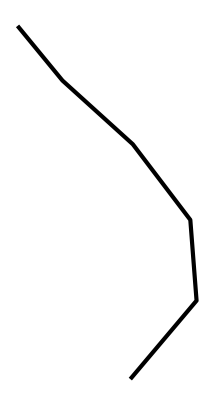

Saved plot to ./logs/synthesis_seq_epoch1.png

Epoch 2/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -45.3383 | Valid Loss: -153.0476
New best model found at epoch 2! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 70
Input seq:  Hello world!  
Length of input sequence:  14


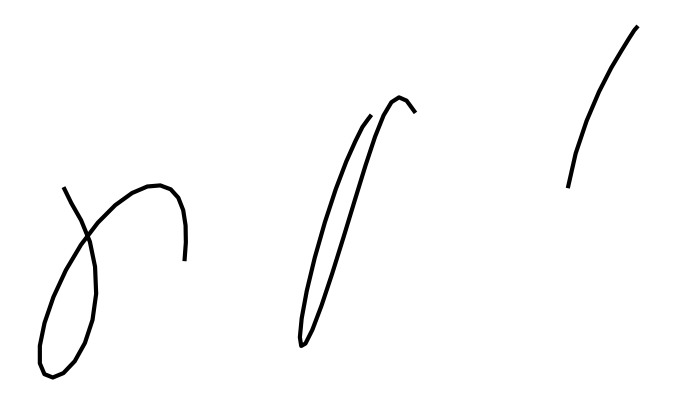

Saved plot to ./logs/synthesis_seq_epoch2.png

Epoch 3/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -116.3205 | Valid Loss: 51.0371

Epoch 4/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -198.1504 | Valid Loss: -248.7843
New best model found at epoch 4! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 92
Input seq:  Hello world!  
Length of input sequence:  14


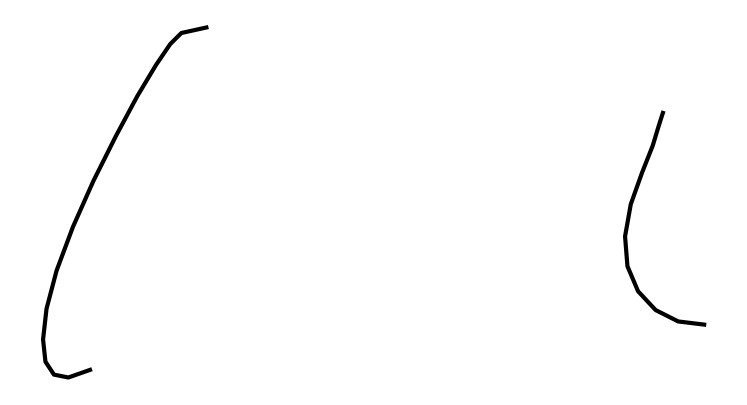

Saved plot to ./logs/synthesis_seq_epoch4.png

Epoch 5/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -249.8634 | Valid Loss: -203.7751

Epoch 6/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -278.3080 | Valid Loss: -307.4355
New best model found at epoch 6! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 53
Input seq:  Hello world!  
Length of input sequence:  14


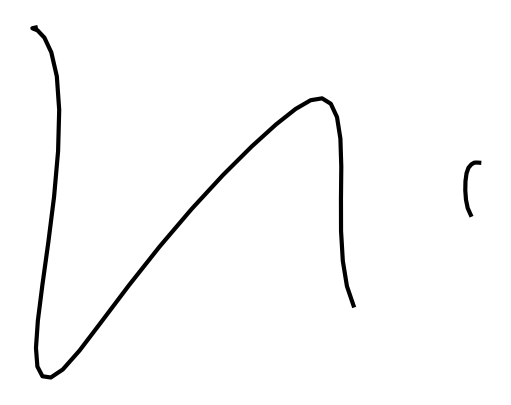

Saved plot to ./logs/synthesis_seq_epoch6.png

Epoch 7/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -296.9498 | Valid Loss: -266.7132

Epoch 8/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -284.4484 | Valid Loss: -284.8351

Epoch 9/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -298.3715 | Valid Loss: -317.5831
New best model found at epoch 9! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 9
Input seq:  Hello world!  
Length of input sequence:  14


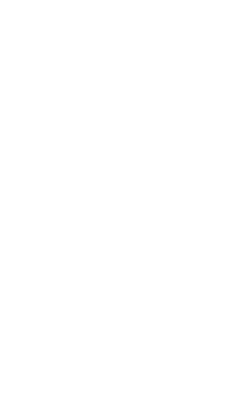

Saved plot to ./logs/synthesis_seq_epoch9.png

Epoch 10/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -356.6532 | Valid Loss: -356.3210
New best model found at epoch 10! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 14
Input seq:  Hello world!  
Length of input sequence:  14


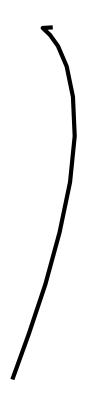

Saved plot to ./logs/synthesis_seq_epoch10.png

Epoch 11/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -372.1351 | Valid Loss: -367.9445
New best model found at epoch 11! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 105
Input seq:  Hello world!  
Length of input sequence:  14


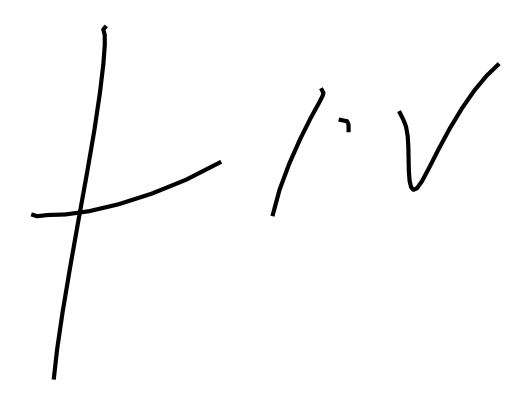

Saved plot to ./logs/synthesis_seq_epoch11.png

Epoch 12/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -396.5270 | Valid Loss: -392.6958
New best model found at epoch 12! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 114
Input seq:  Hello world!  
Length of input sequence:  14


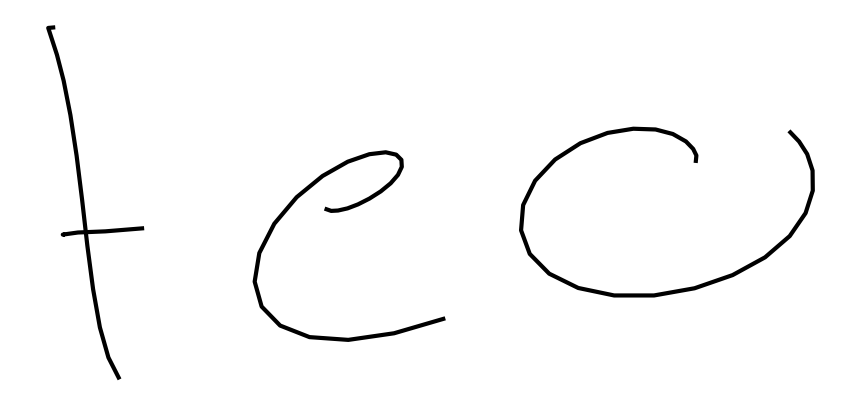

Saved plot to ./logs/synthesis_seq_epoch12.png

Epoch 13/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -404.9191 | Valid Loss: -386.2239

Epoch 14/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -412.7805 | Valid Loss: -386.9309

Epoch 15/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -425.5141 | Valid Loss: -428.5160
New best model found at epoch 15! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 102
Input seq:  Hello world!  
Length of input sequence:  14


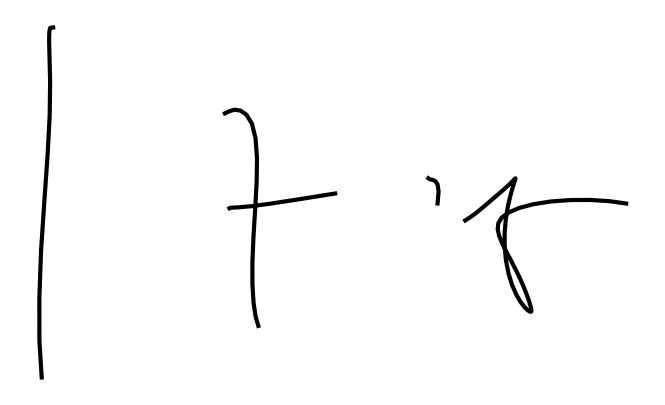

Saved plot to ./logs/synthesis_seq_epoch15.png

Epoch 16/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -429.2673 | Valid Loss: -416.1381

Epoch 17/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -440.8070 | Valid Loss: -446.3268
New best model found at epoch 17! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 106
Input seq:  Hello world!  
Length of input sequence:  14


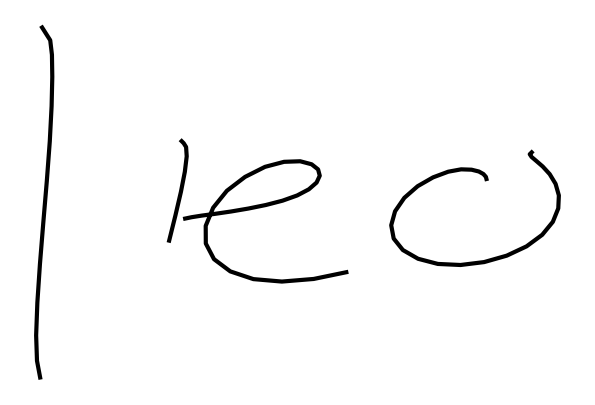

Saved plot to ./logs/synthesis_seq_epoch17.png

Epoch 18/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -451.5962 | Valid Loss: -426.3913

Epoch 19/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -466.3195 | Valid Loss: -445.7089

Epoch 21/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -472.8758 | Valid Loss: -455.6020
New best model found at epoch 21! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 223
Input seq:  Hello world!  
Length of input sequence:  14


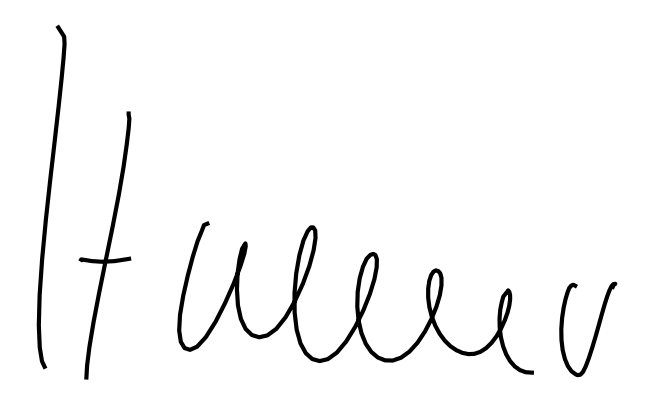

Saved plot to ./logs/synthesis_seq_epoch21.png

Epoch 22/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -477.0301 | Valid Loss: -452.3062

Epoch 23/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -486.4257 | Valid Loss: -480.1158
New best model found at epoch 23! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 438
Input seq:  Hello world!  
Length of input sequence:  14


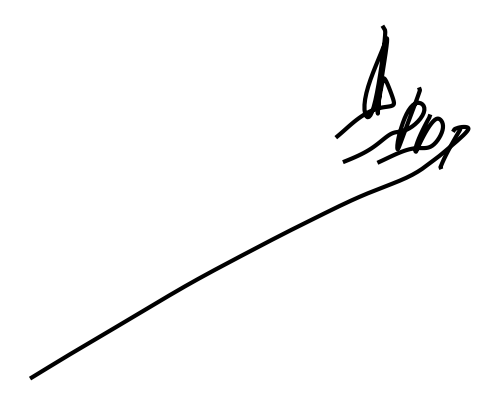

Saved plot to ./logs/synthesis_seq_epoch23.png

Epoch 24/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -489.6528 | Valid Loss: -477.4488

Epoch 25/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -487.8382 | Valid Loss: -480.1210
New best model found at epoch 25! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 290
Input seq:  Hello world!  
Length of input sequence:  14


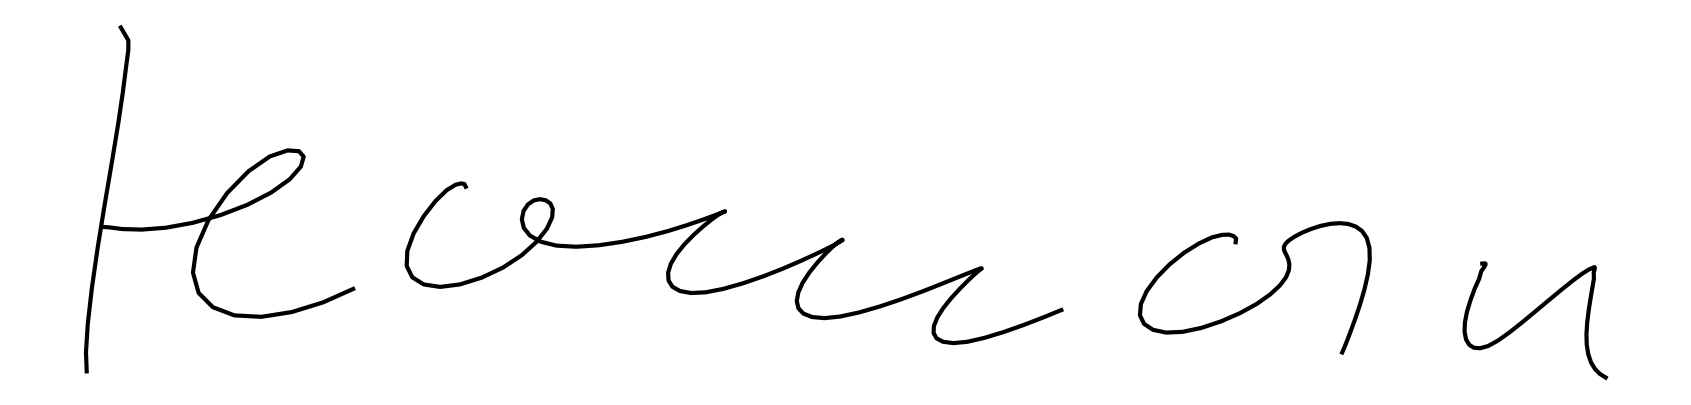

Saved plot to ./logs/synthesis_seq_epoch25.png

Epoch 26/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -486.8446 | Valid Loss: -476.9238

Epoch 27/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -495.9277 | Valid Loss: -480.3336
New best model found at epoch 27! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 301
Input seq:  Hello world!  
Length of input sequence:  14


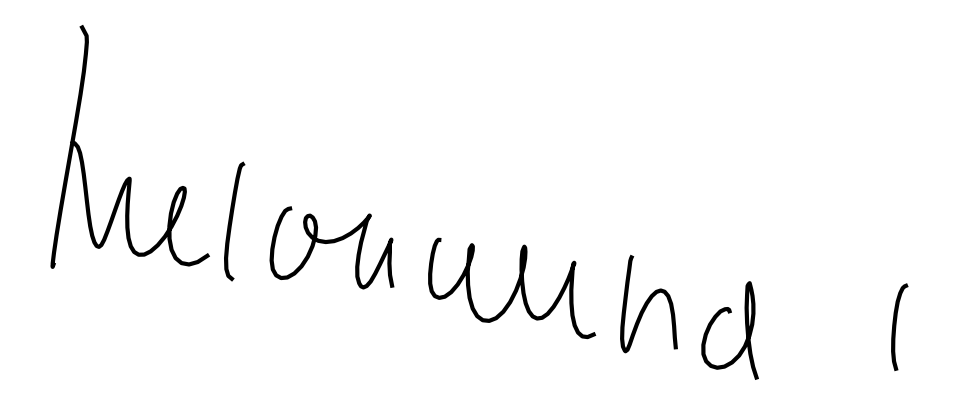

Saved plot to ./logs/synthesis_seq_epoch27.png

Epoch 28/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -515.3058 | Valid Loss: -523.5572
New best model found at epoch 28! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 333
Input seq:  Hello world!  
Length of input sequence:  14


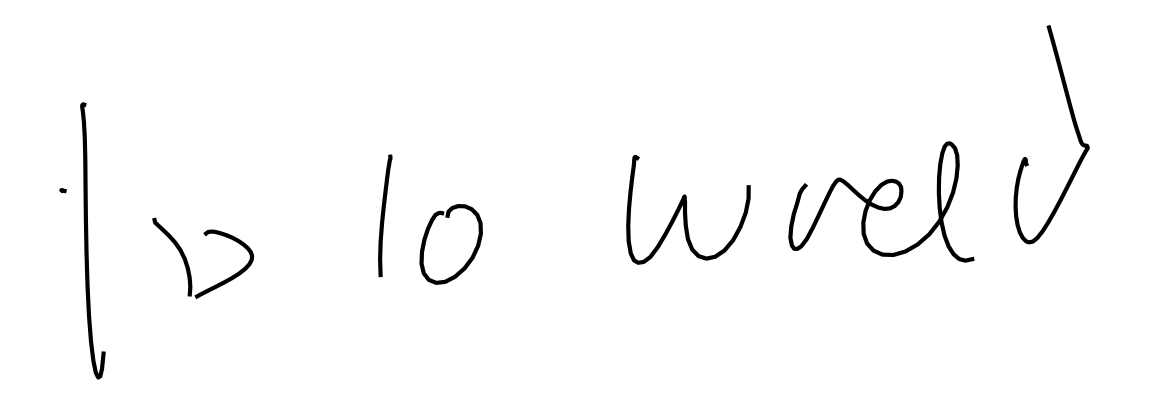

Saved plot to ./logs/synthesis_seq_epoch28.png

Epoch 29/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -527.6163 | Valid Loss: -502.1418

Epoch 30/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -522.5971 | Valid Loss: -521.1864

Epoch 31/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -539.7385 | Valid Loss: -536.1372
New best model found at epoch 31! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 531
Input seq:  Hello world!  
Length of input sequence:  14


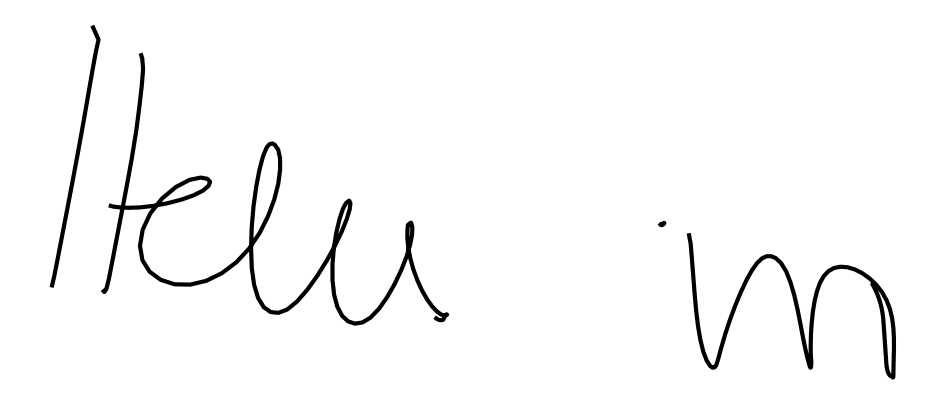

Saved plot to ./logs/synthesis_seq_epoch31.png

Epoch 32/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -539.7330 | Valid Loss: -514.9294

Epoch 33/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -547.4393 | Valid Loss: -552.6042
New best model found at epoch 33! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 278
Input seq:  Hello world!  
Length of input sequence:  14


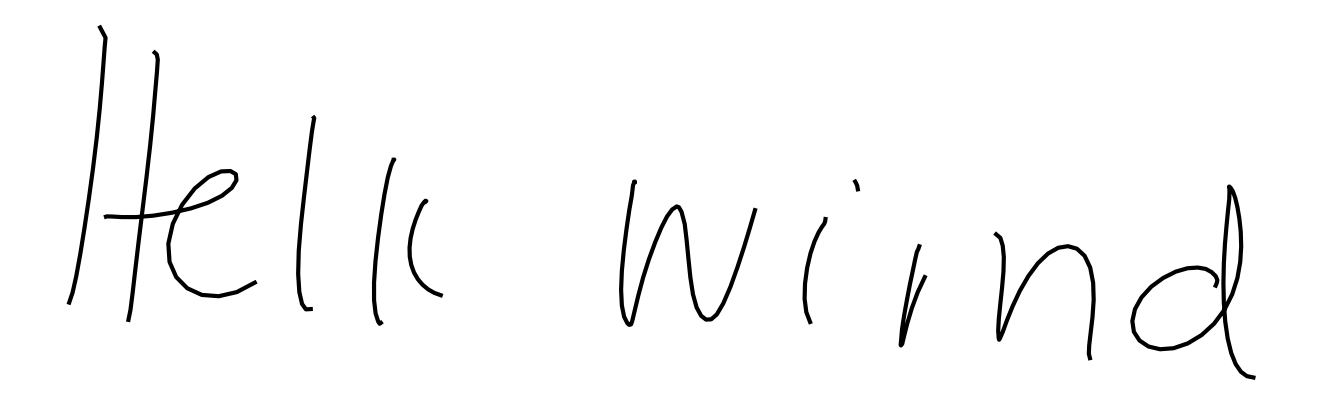

Saved plot to ./logs/synthesis_seq_epoch33.png

Epoch 34/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -543.0626 | Valid Loss: -541.4709

Epoch 35/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -552.2105 | Valid Loss: -532.5066

Epoch 36/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -570.3782 | Valid Loss: -583.9422
New best model found at epoch 36! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 331
Input seq:  Hello world!  
Length of input sequence:  14


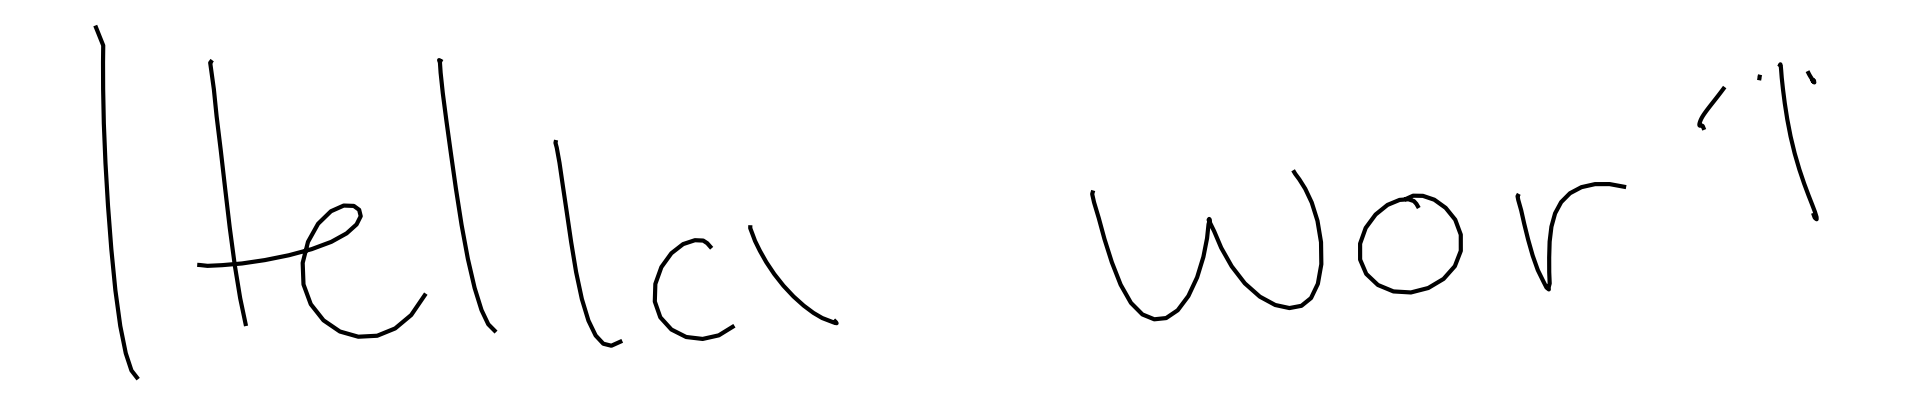

Saved plot to ./logs/synthesis_seq_epoch36.png

Epoch 37/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -586.0721 | Valid Loss: -587.2695
New best model found at epoch 37! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 328
Input seq:  Hello world!  
Length of input sequence:  14


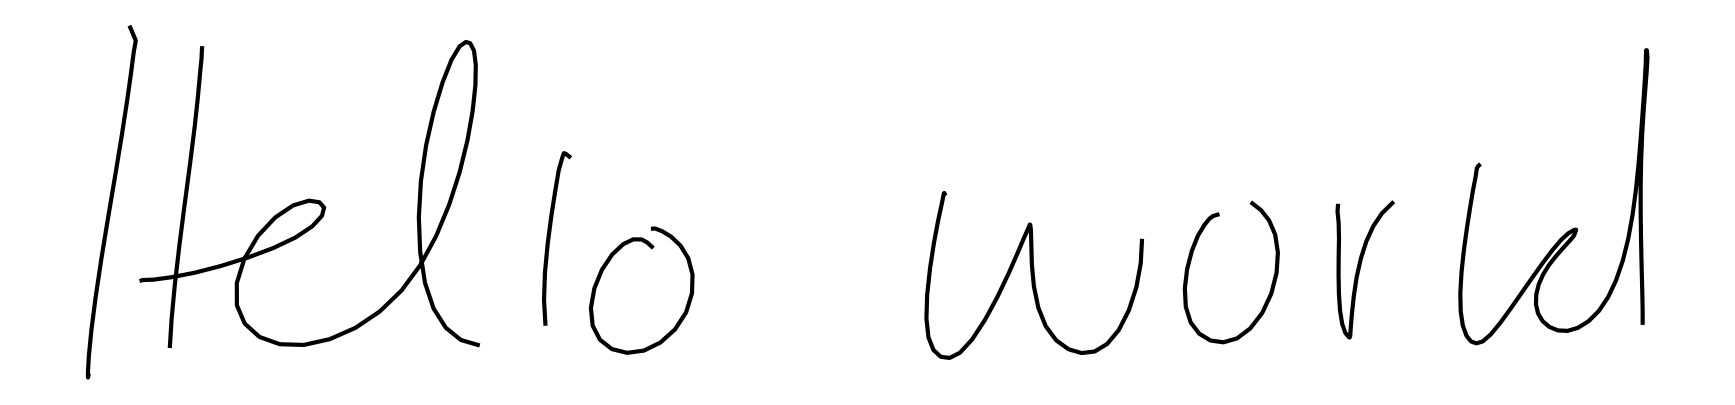

Saved plot to ./logs/synthesis_seq_epoch37.png

Epoch 38/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -585.2786 | Valid Loss: -584.7157

Epoch 39/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -593.1541 | Valid Loss: -600.5146
New best model found at epoch 39! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 321
Input seq:  Hello world!  
Length of input sequence:  14


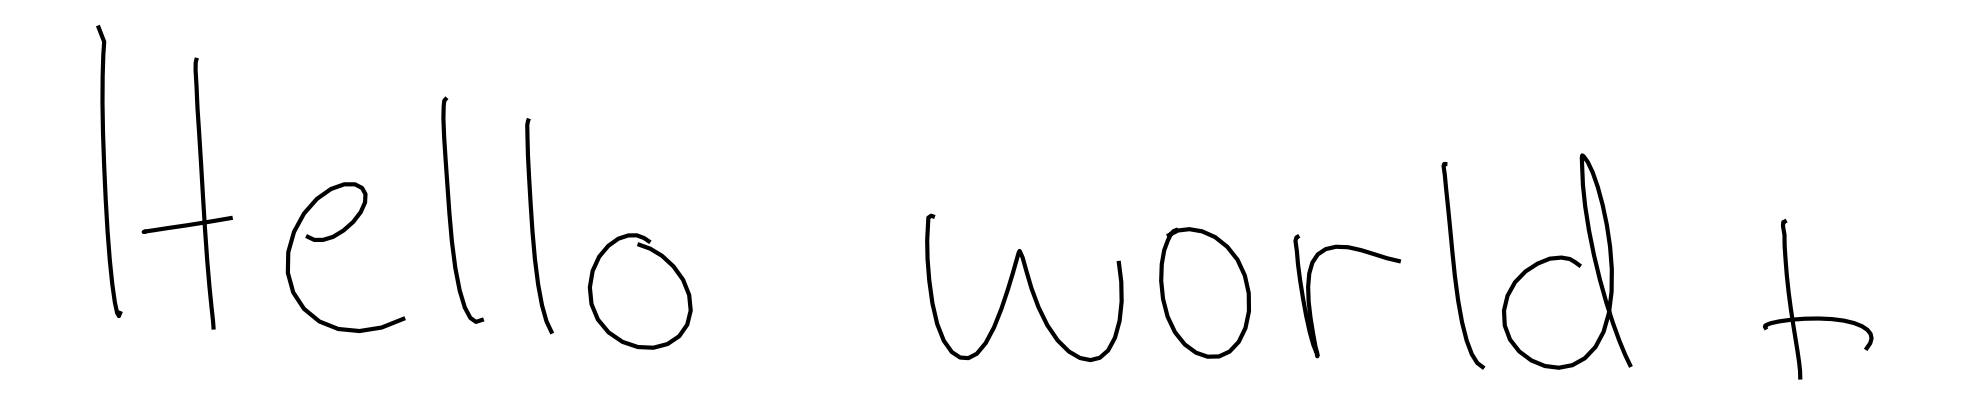

Saved plot to ./logs/synthesis_seq_epoch39.png

Epoch 40/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -588.1660 | Valid Loss: -592.5032

Epoch 41/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -610.7404 | Valid Loss: -616.6729
New best model found at epoch 41! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 300
Input seq:  Hello world!  
Length of input sequence:  14


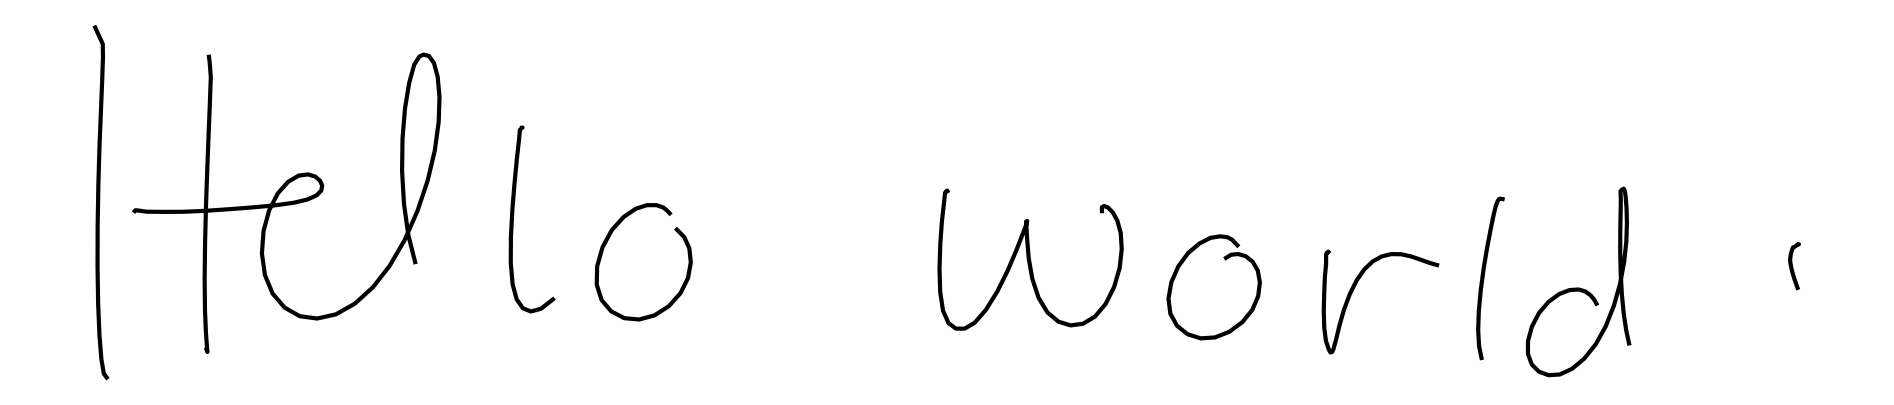

Saved plot to ./logs/synthesis_seq_epoch41.png

Epoch 42/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -621.4994 | Valid Loss: -575.3735

Epoch 43/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -642.4728 | Valid Loss: -616.3515

Epoch 50/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -635.7745 | Valid Loss: -630.6817
New best model found at epoch 50! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 339
Input seq:  Hello world!  
Length of input sequence:  14


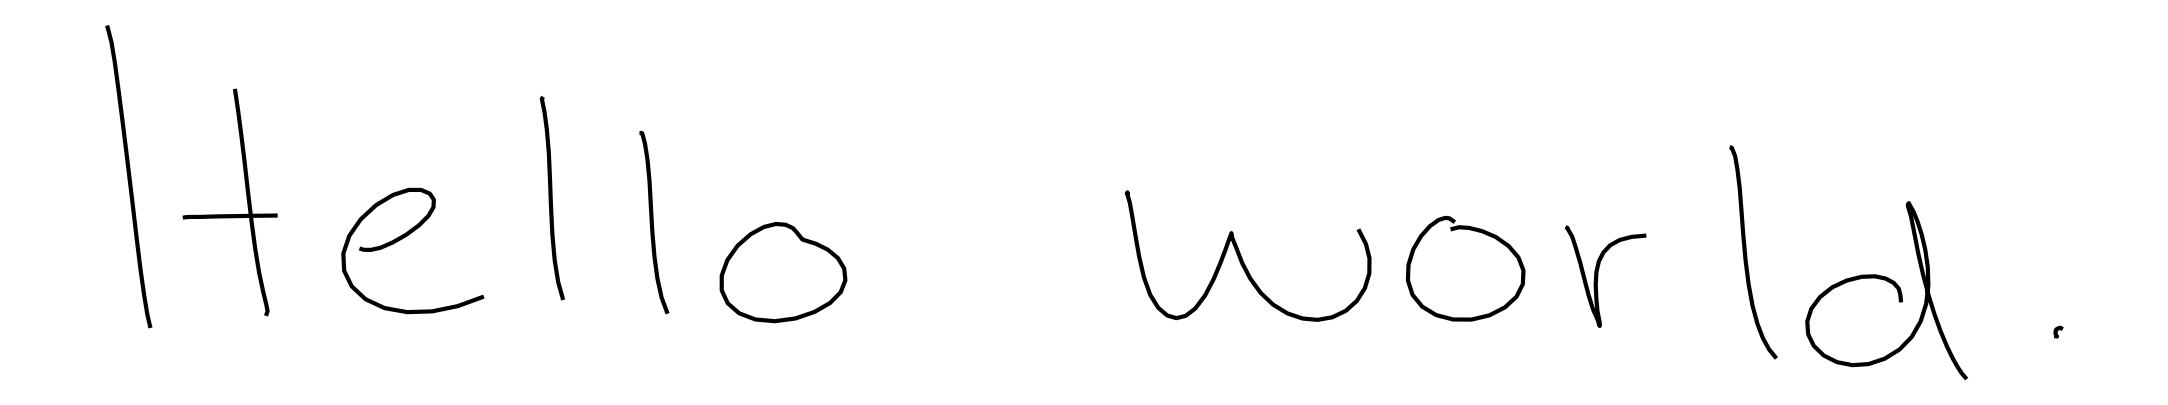

Saved plot to ./logs/synthesis_seq_epoch50.png

Epoch 51/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -664.1098 | Valid Loss: -655.1373
New best model found at epoch 51! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 330
Input seq:  Hello world!  
Length of input sequence:  14


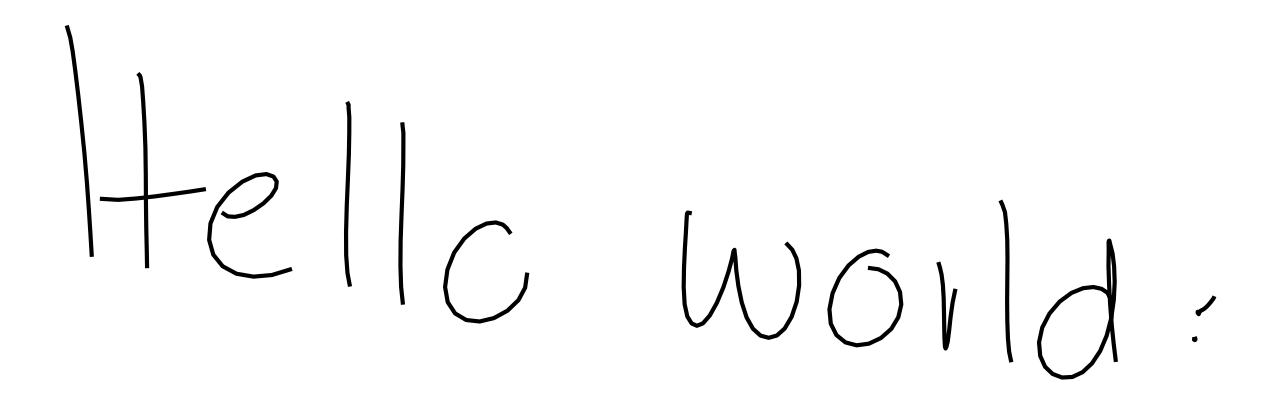

Saved plot to ./logs/synthesis_seq_epoch51.png

Epoch 52/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -674.6515 | Valid Loss: -653.2012

Epoch 53/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -682.9335 | Valid Loss: -686.2376
New best model found at epoch 53! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 261
Input seq:  Hello world!  
Length of input sequence:  14


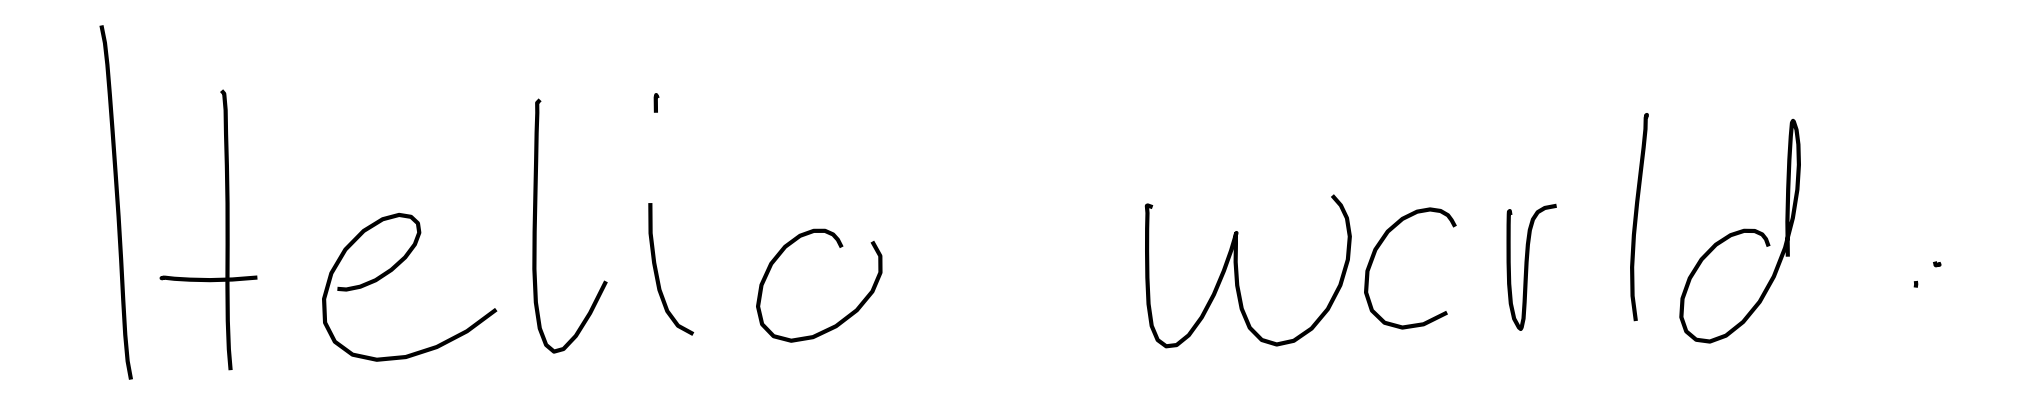

Saved plot to ./logs/synthesis_seq_epoch53.png

Epoch 54/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -686.3139 | Valid Loss: -670.4817

Epoch 55/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -688.7294 | Valid Loss: -672.6884

Epoch 57/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -700.6377 | Valid Loss: -692.8751
New best model found at epoch 57! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 273
Input seq:  Hello world!  
Length of input sequence:  14


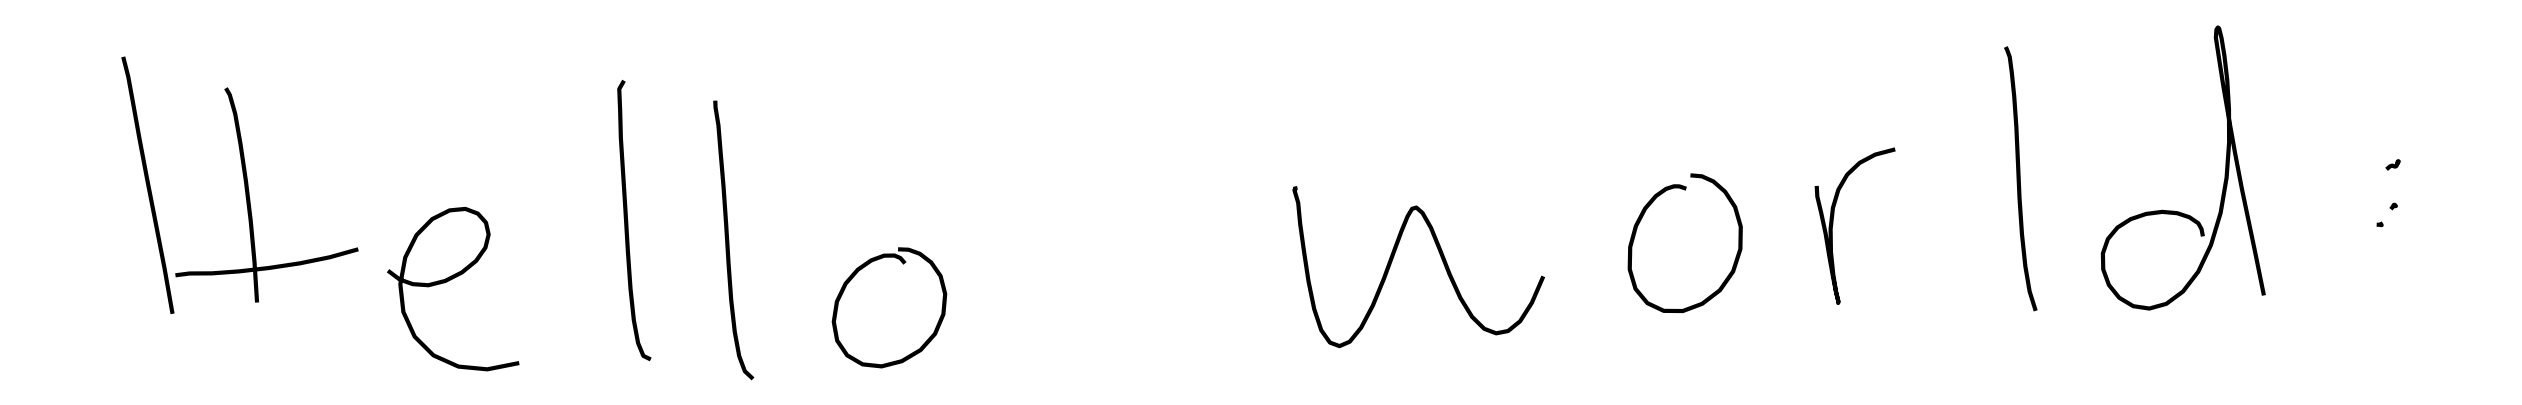

Saved plot to ./logs/synthesis_seq_epoch57.png

Epoch 58/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -705.4307 | Valid Loss: -691.0310

Epoch 59/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -704.6882 | Valid Loss: -694.3551
New best model found at epoch 59! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 265
Input seq:  Hello world!  
Length of input sequence:  14


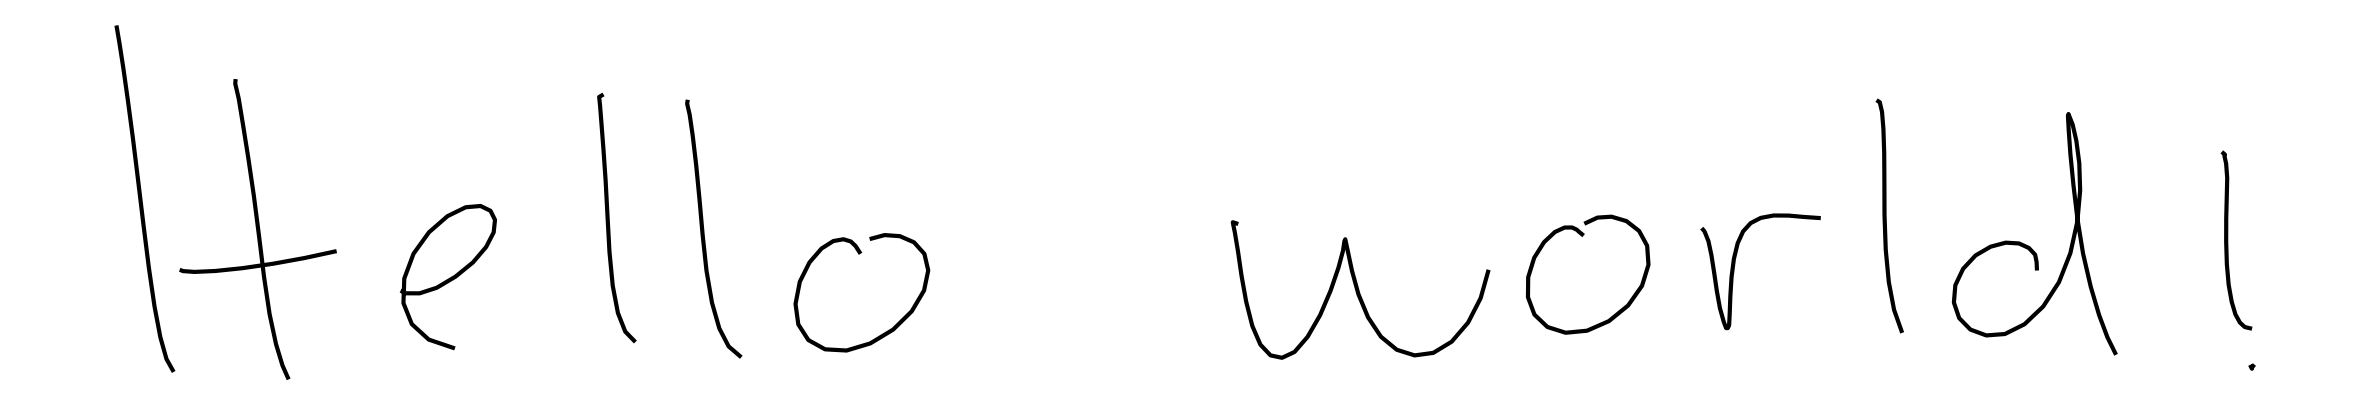

Saved plot to ./logs/synthesis_seq_epoch59.png

Epoch 60/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -703.2971 | Valid Loss: -689.3544

Epoch 61/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -696.9391 | Valid Loss: -679.4043

Epoch 63/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -715.2380 | Valid Loss: -704.5832
New best model found at epoch 63! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 308
Input seq:  Hello world!  
Length of input sequence:  14


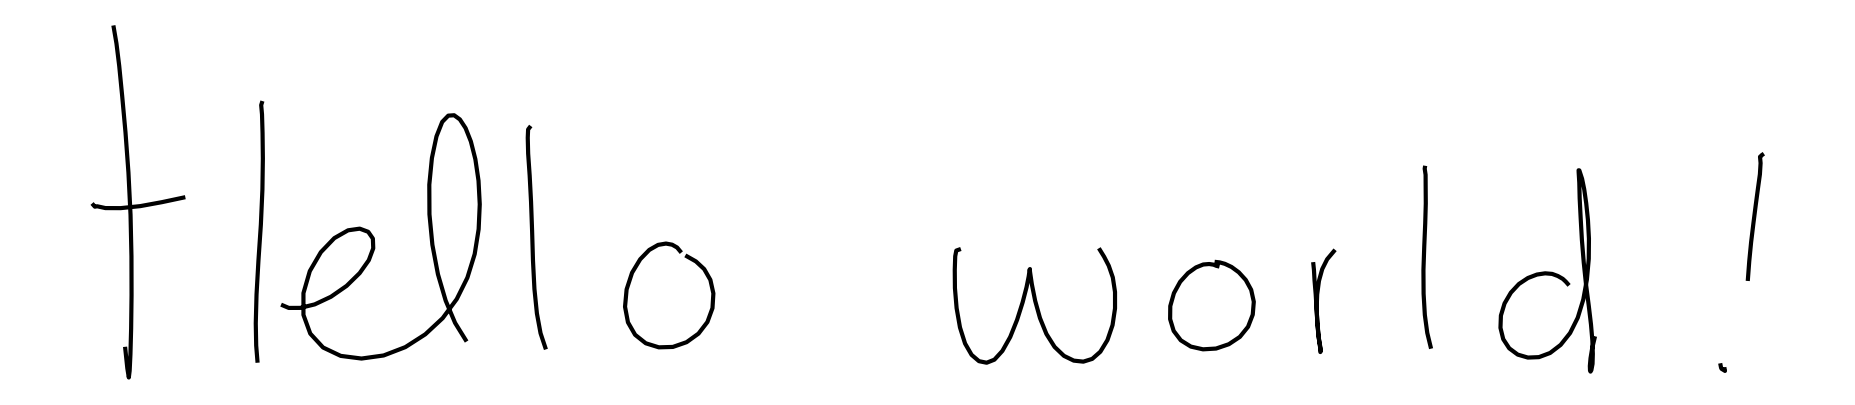

Saved plot to ./logs/synthesis_seq_epoch63.png

Epoch 64/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -714.1364 | Valid Loss: -663.7358

Epoch 65/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -712.1533 | Valid Loss: -697.4893

Epoch 66/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -715.1397 | Valid Loss: -708.1822
New best model found at epoch 66! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 402
Input seq:  Hello world!  
Length of input sequence:  14


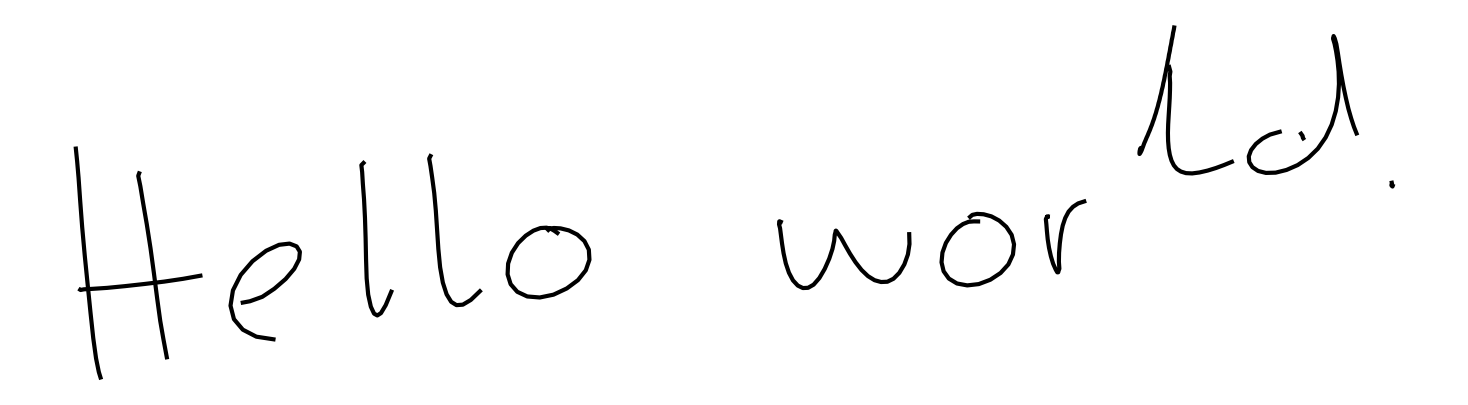

Saved plot to ./logs/synthesis_seq_epoch66.png

Epoch 67/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -714.5874 | Valid Loss: -714.8698
New best model found at epoch 67! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 333
Input seq:  Hello world!  
Length of input sequence:  14


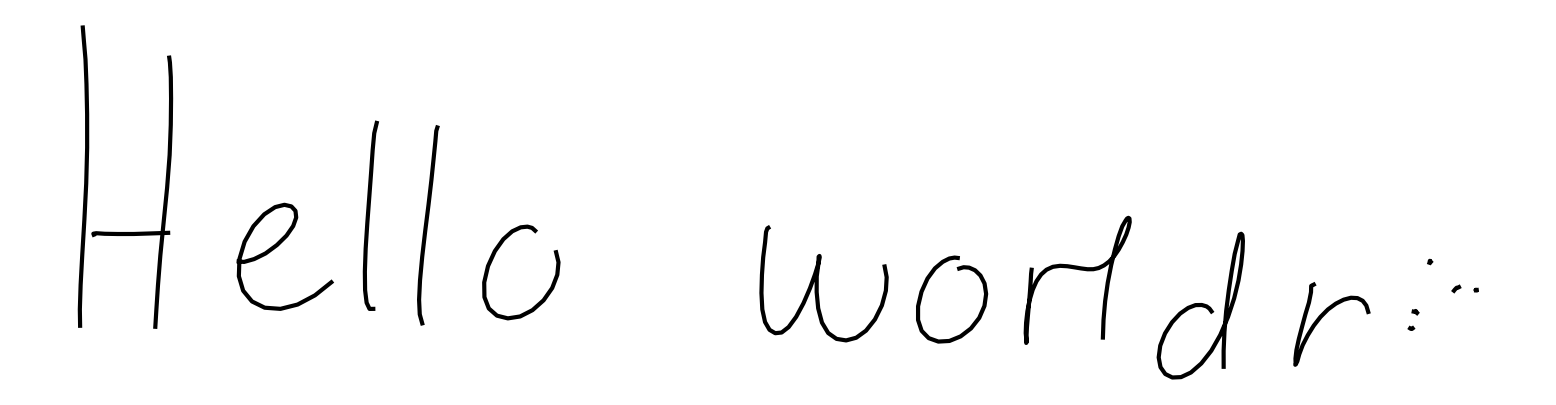

Saved plot to ./logs/synthesis_seq_epoch67.png

Epoch 68/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -721.2636 | Valid Loss: -680.8870

Epoch 69/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -714.2071 | Valid Loss: -715.4626
New best model found at epoch 69! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 248
Input seq:  Hello world!  
Length of input sequence:  14


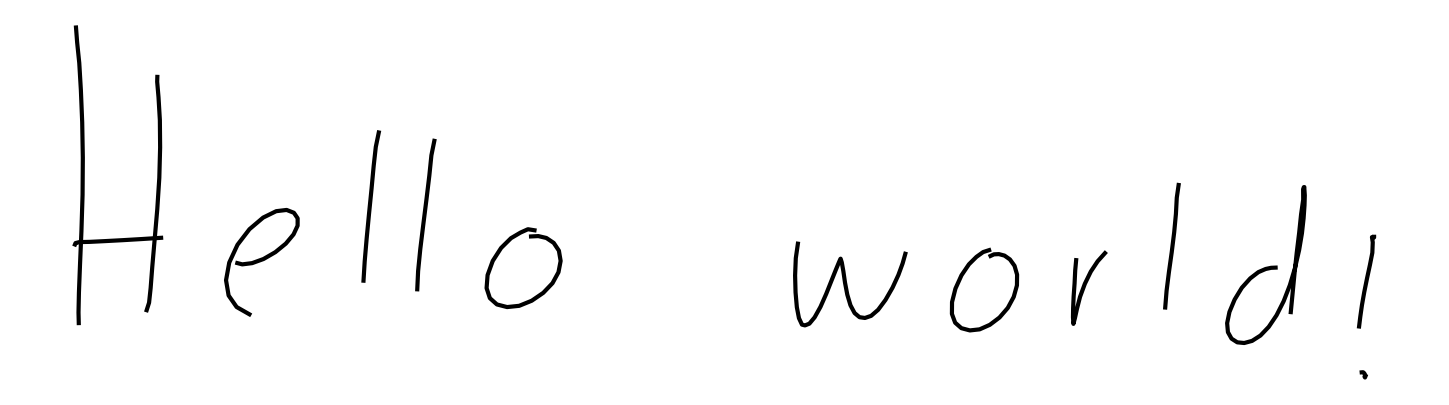

Saved plot to ./logs/synthesis_seq_epoch69.png

Epoch 70/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -723.6326 | Valid Loss: -692.8171

Epoch 71/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -737.2838 | Valid Loss: -695.3985

Epoch 72/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -721.7030 | Valid Loss: -723.4699
New best model found at epoch 72! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 248
Input seq:  Hello world!  
Length of input sequence:  14


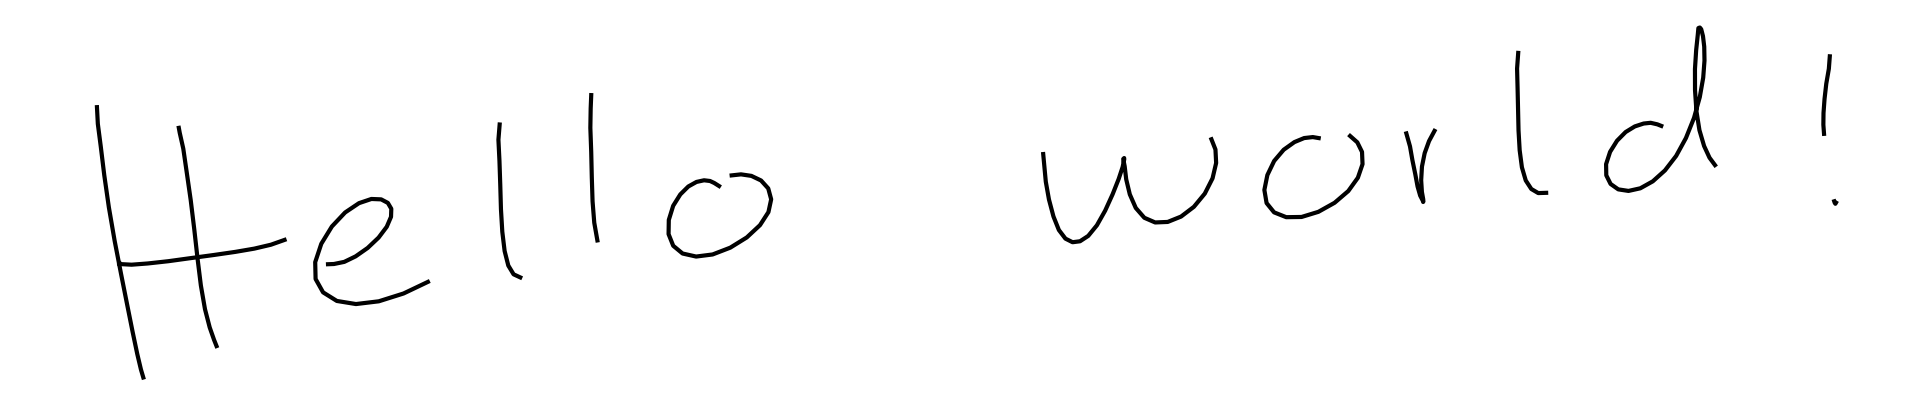

Saved plot to ./logs/synthesis_seq_epoch72.png

Epoch 73/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -725.8392 | Valid Loss: -699.0592

Epoch 74/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -728.7916 | Valid Loss: -730.1507
New best model found at epoch 74! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 275
Input seq:  Hello world!  
Length of input sequence:  14


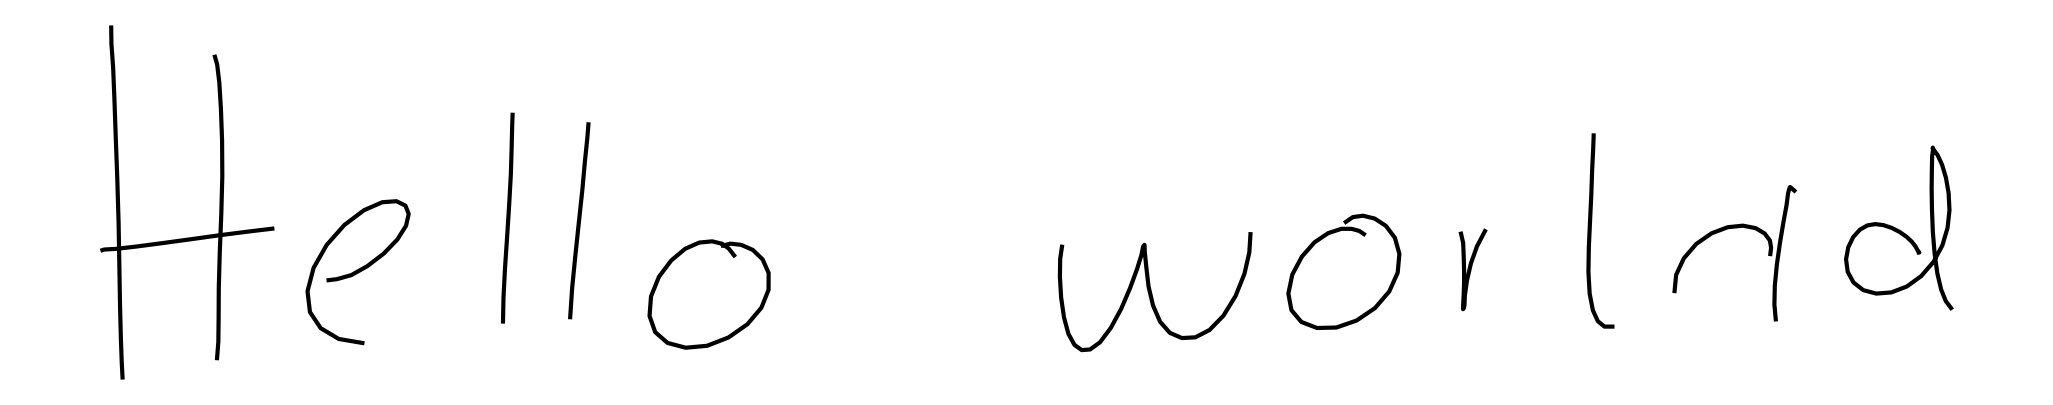

Saved plot to ./logs/synthesis_seq_epoch74.png

Epoch 75/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -733.4523 | Valid Loss: -715.8316

Epoch 76/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -738.6927 | Valid Loss: -741.2886
New best model found at epoch 76! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 281
Input seq:  Hello world!  
Length of input sequence:  14


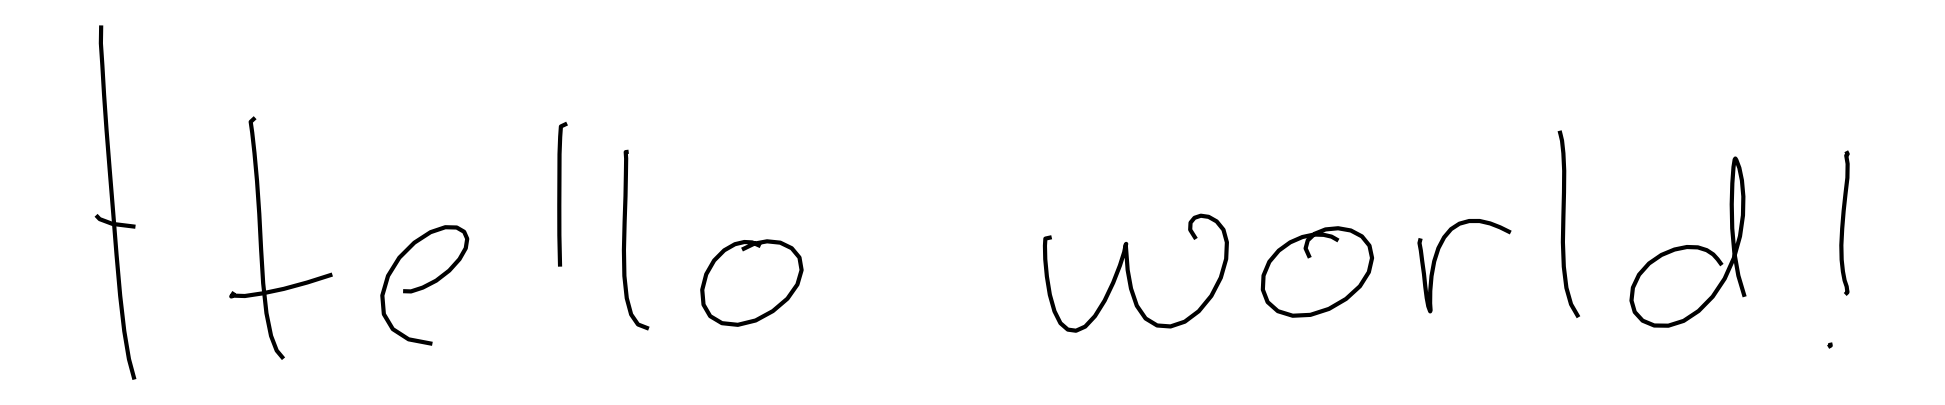

Saved plot to ./logs/synthesis_seq_epoch76.png

Epoch 77/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -754.6832 | Valid Loss: -739.1094

Epoch 78/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -750.5840 | Valid Loss: -750.1424
New best model found at epoch 78! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 301
Input seq:  Hello world!  
Length of input sequence:  14


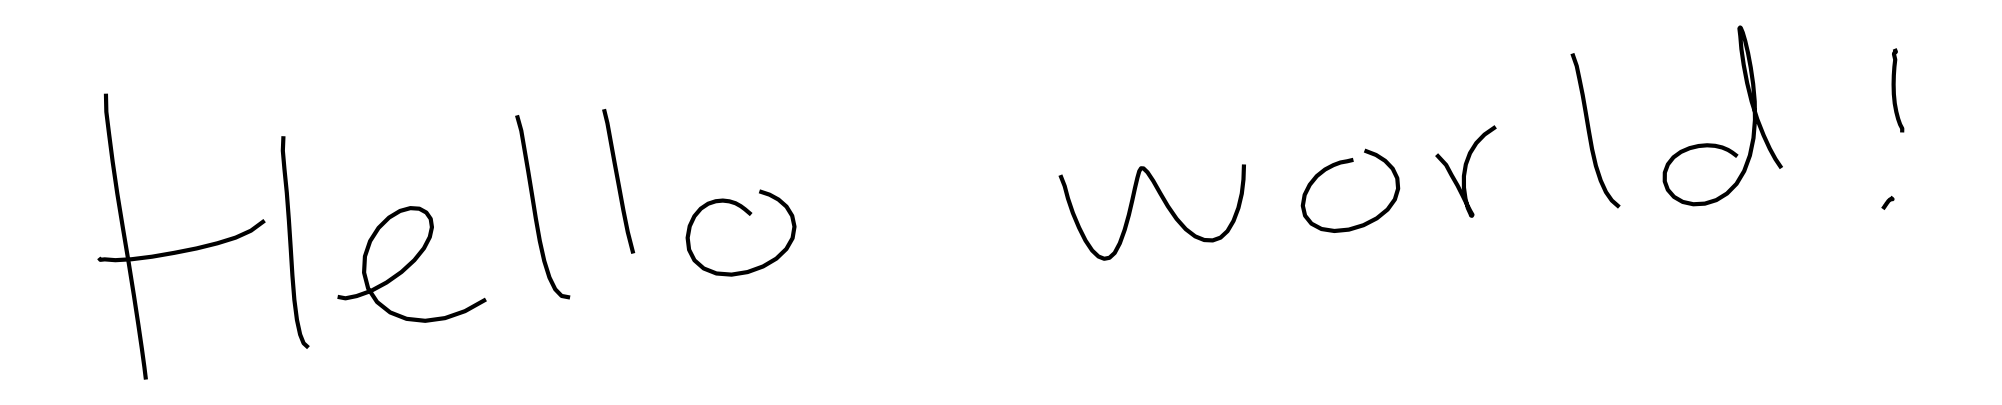

Saved plot to ./logs/synthesis_seq_epoch78.png

Epoch 79/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -740.6562 | Valid Loss: -688.7346

Epoch 80/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -753.2104 | Valid Loss: -740.0439

Epoch 90/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -766.3630 | Valid Loss: -760.4921
New best model found at epoch 90! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 230
Input seq:  Hello world!  
Length of input sequence:  14


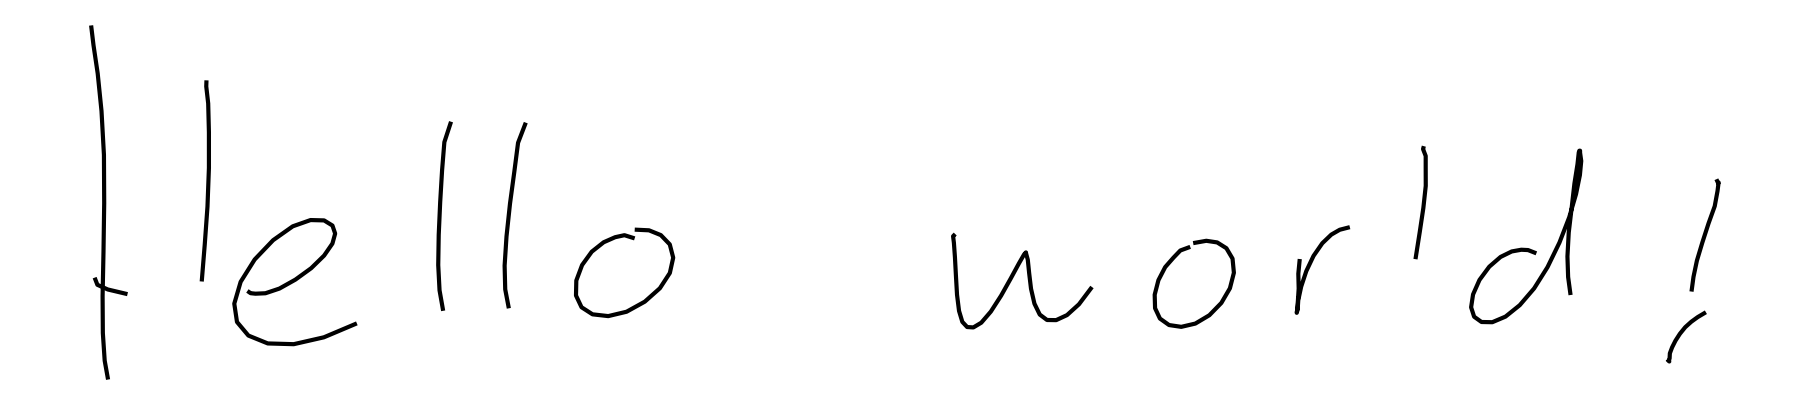

Saved plot to ./logs/synthesis_seq_epoch90.png

Epoch 91/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -760.2969 | Valid Loss: -752.5236

Epoch 92/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -751.5272 | Valid Loss: -742.9726

Epoch 94/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -760.6929 | Valid Loss: -764.8876
New best model found at epoch 94! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 314
Input seq:  Hello world!  
Length of input sequence:  14


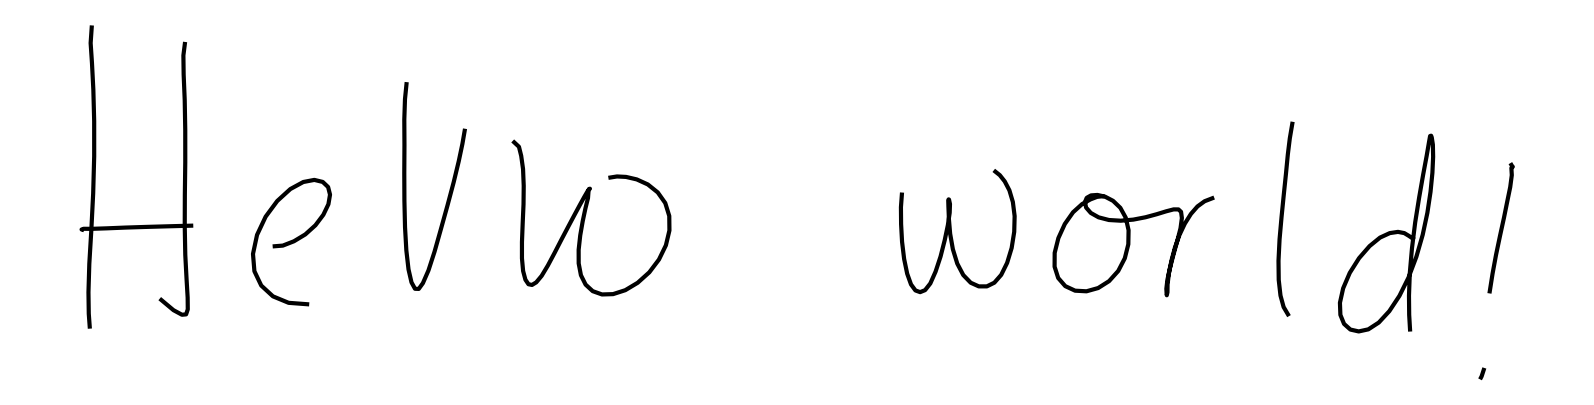

Saved plot to ./logs/synthesis_seq_epoch94.png

Epoch 95/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -778.3305 | Valid Loss: -748.2983

Epoch 96/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -775.0536 | Valid Loss: -770.3524
New best model found at epoch 96! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 286
Input seq:  Hello world!  
Length of input sequence:  14


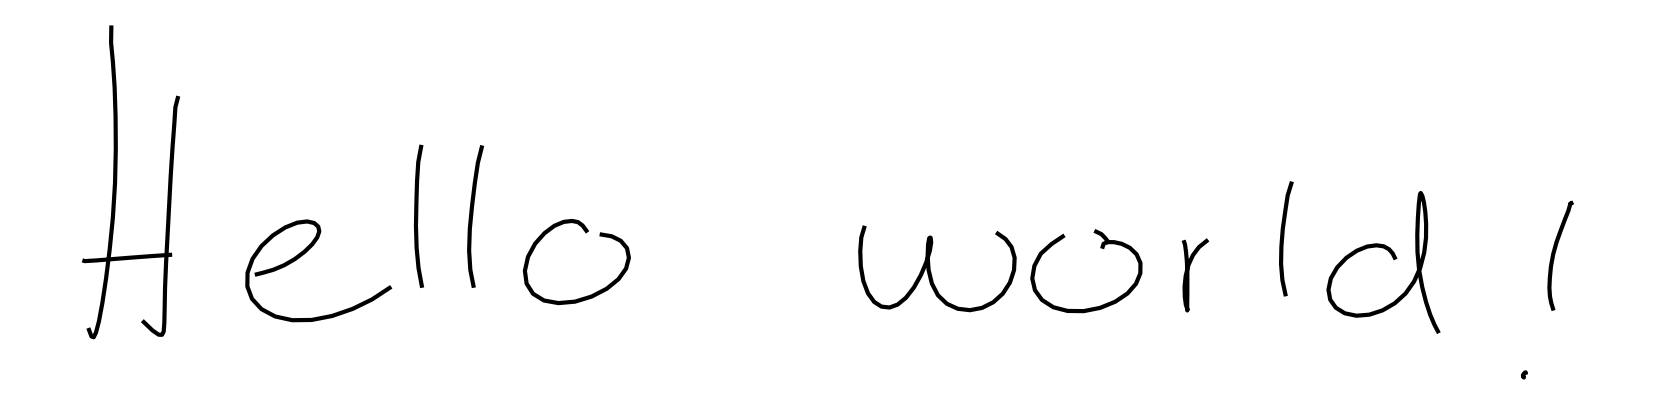

Saved plot to ./logs/synthesis_seq_epoch96.png

Epoch 97/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -787.4498 | Valid Loss: -779.0060
New best model found at epoch 97! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 245
Input seq:  Hello world!  
Length of input sequence:  14


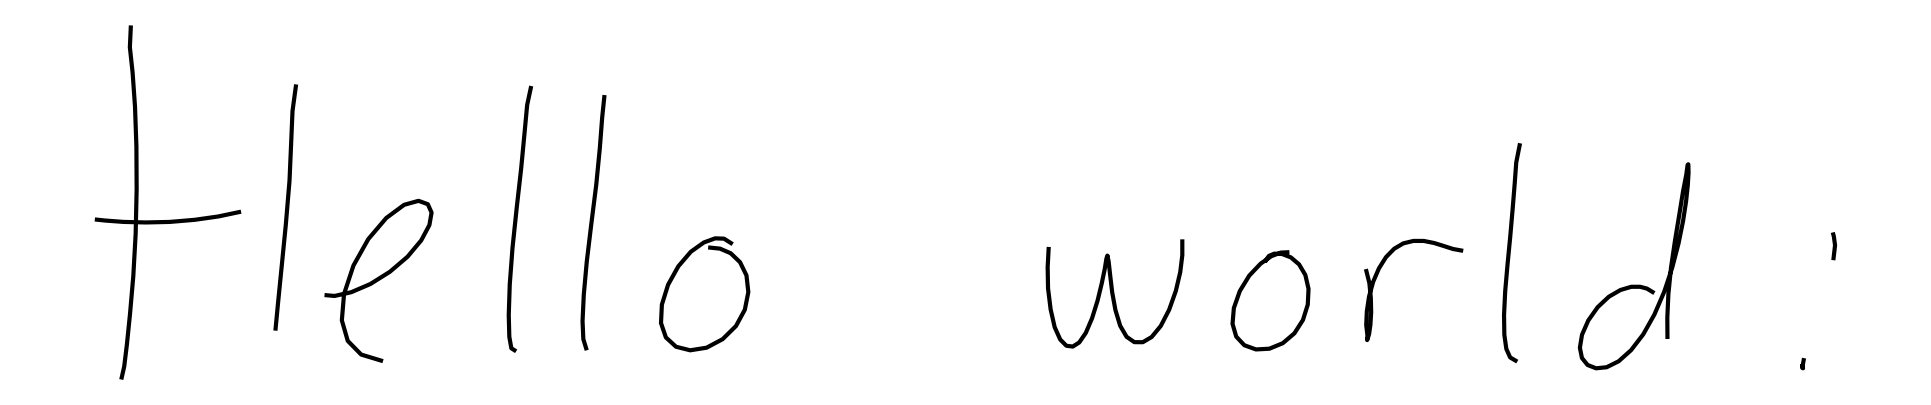

Saved plot to ./logs/synthesis_seq_epoch97.png

Epoch 98/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -783.2559 | Valid Loss: -752.2926

Epoch 99/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -726.0390 | Valid Loss: -773.7093

Epoch 101/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -815.6891 | Valid Loss: -806.1837
New best model found at epoch 101! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 238
Input seq:  Hello world!  
Length of input sequence:  14


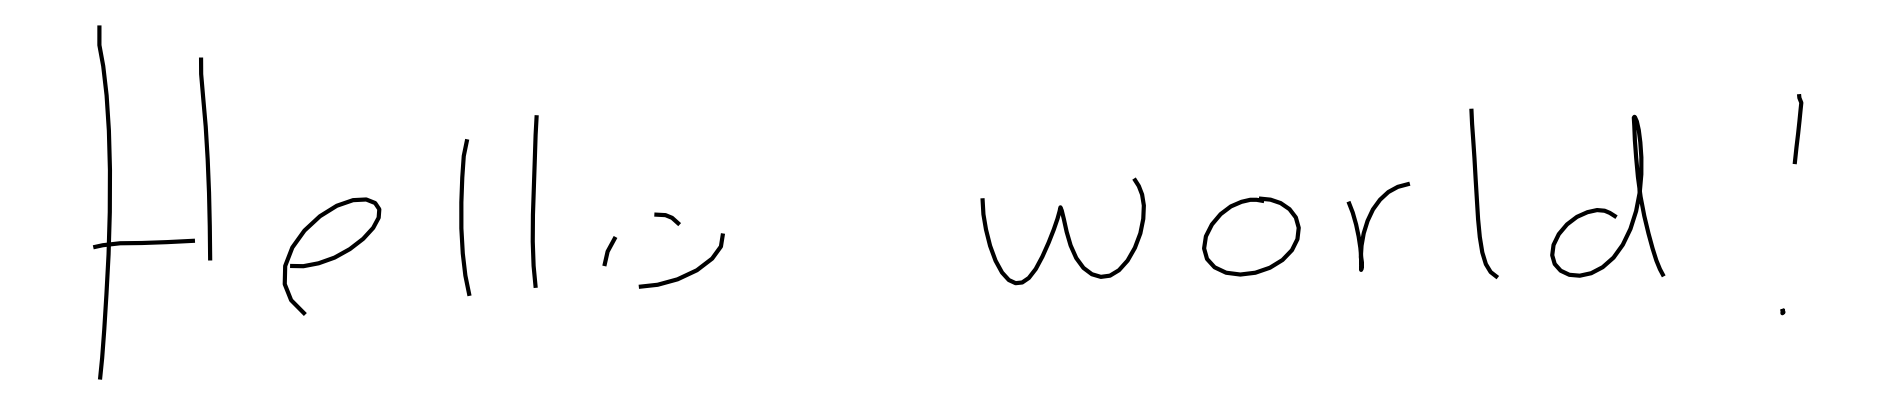

Saved plot to ./logs/synthesis_seq_epoch101.png

Epoch 102/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -826.1497 | Valid Loss: -811.2604
New best model found at epoch 102! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 269
Input seq:  Hello world!  
Length of input sequence:  14


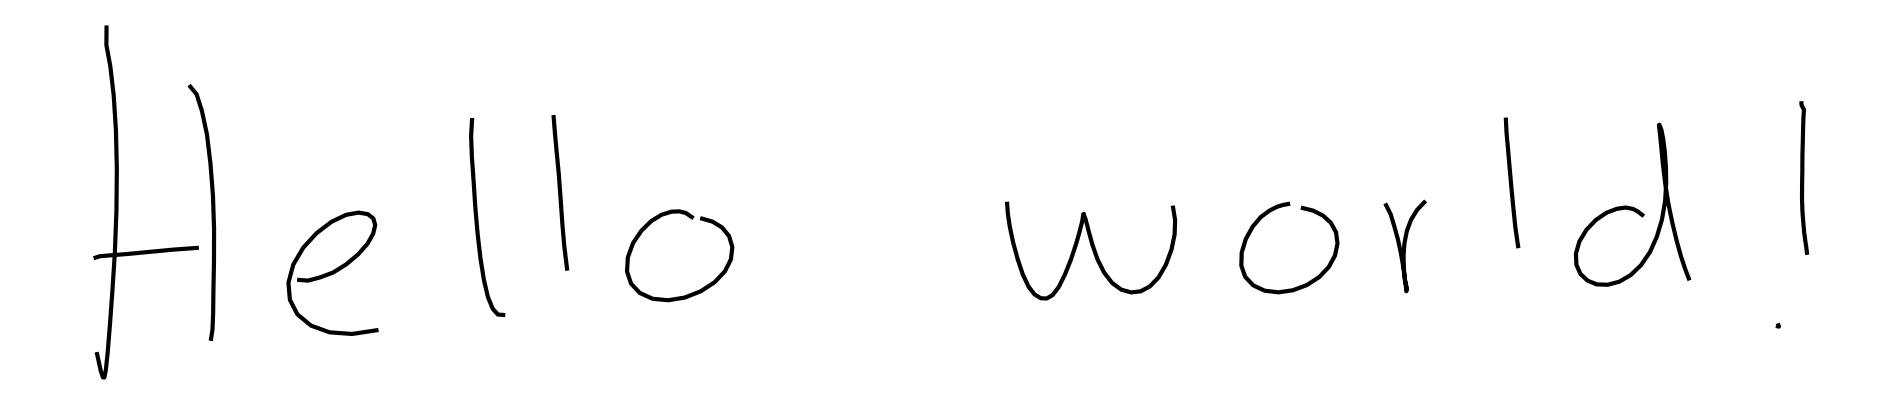

Saved plot to ./logs/synthesis_seq_epoch102.png

Epoch 103/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -829.8358 | Valid Loss: -812.8359
New best model found at epoch 103! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 266
Input seq:  Hello world!  
Length of input sequence:  14


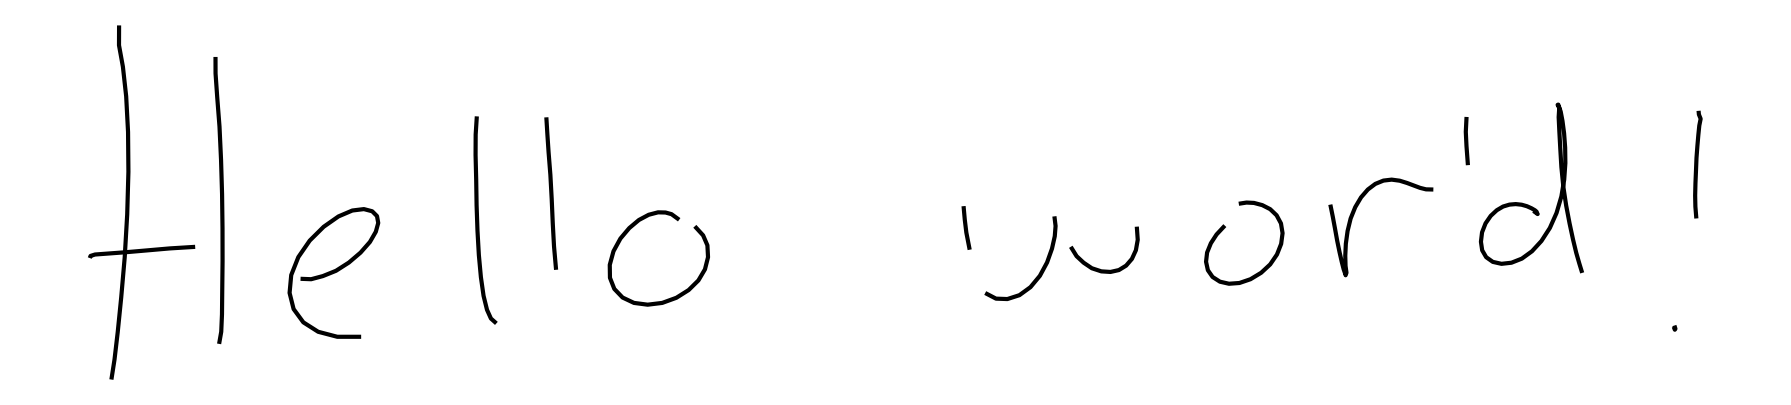

Saved plot to ./logs/synthesis_seq_epoch103.png

Epoch 104/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -832.5199 | Valid Loss: -814.8972
New best model found at epoch 104! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 454
Input seq:  Hello world!  
Length of input sequence:  14


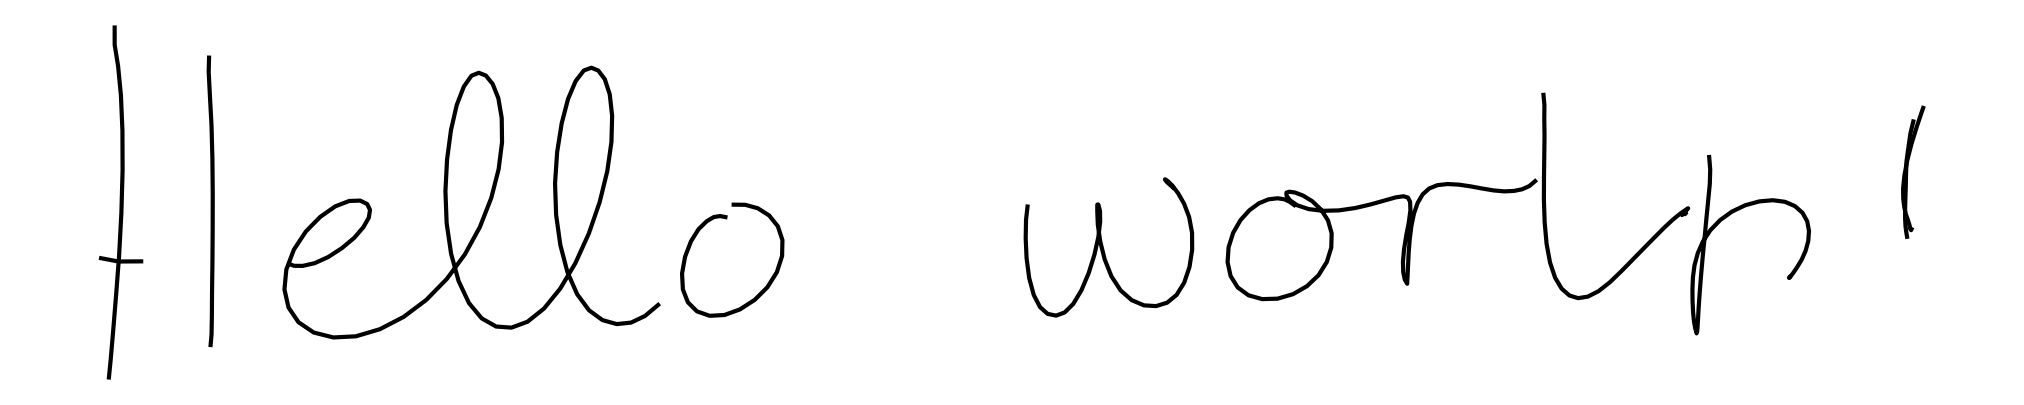

Saved plot to ./logs/synthesis_seq_epoch104.png

Epoch 105/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -834.4644 | Valid Loss: -817.5904
New best model found at epoch 105! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 285
Input seq:  Hello world!  
Length of input sequence:  14


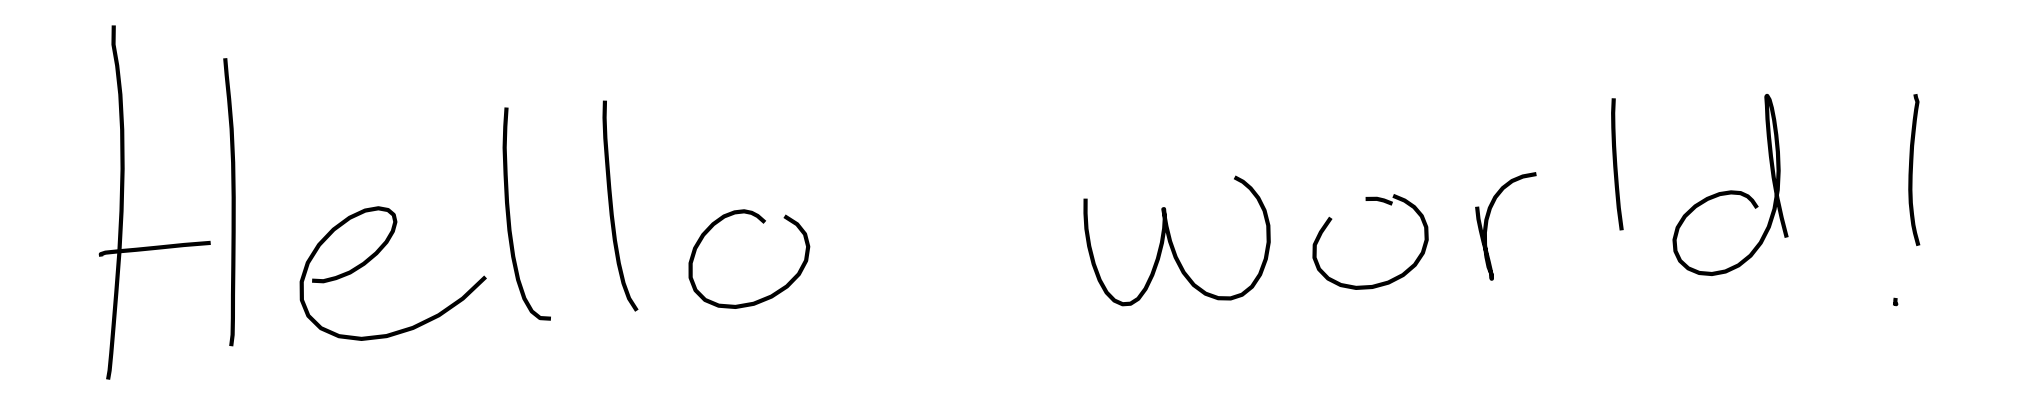

Saved plot to ./logs/synthesis_seq_epoch105.png

Epoch 106/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -836.5047 | Valid Loss: -818.5043
New best model found at epoch 106! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 220
Input seq:  Hello world!  
Length of input sequence:  14


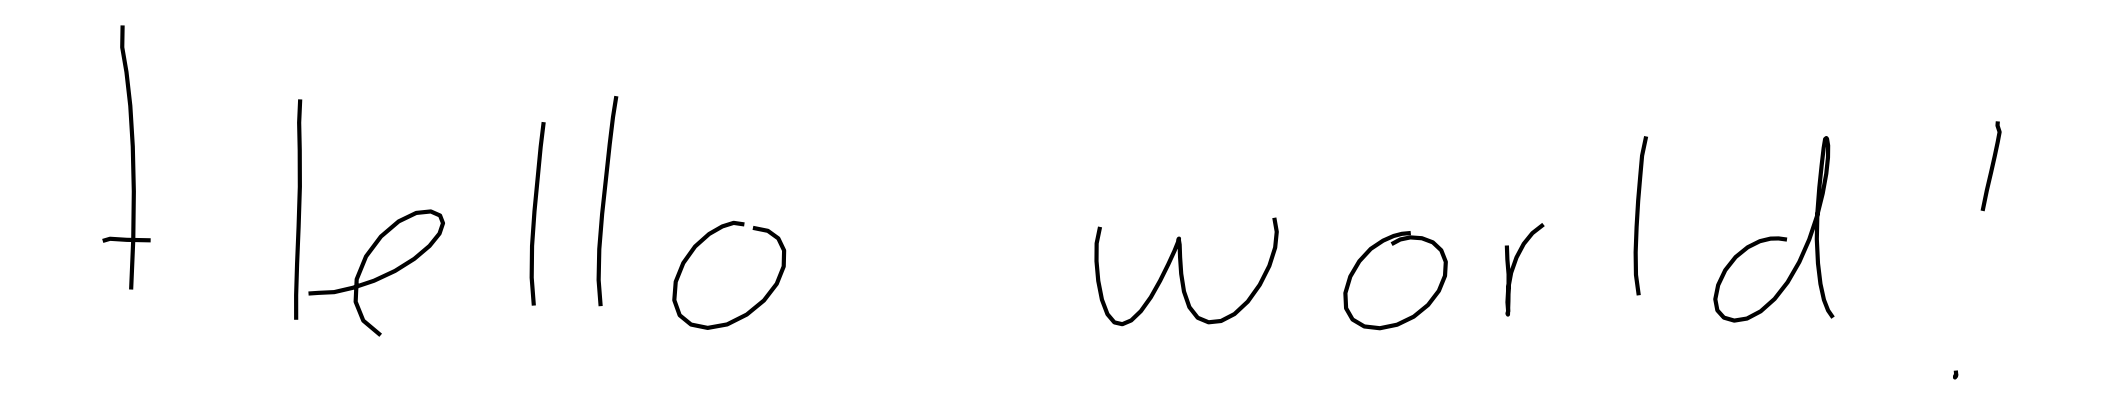

Saved plot to ./logs/synthesis_seq_epoch106.png

Epoch 107/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -838.0890 | Valid Loss: -821.0870
New best model found at epoch 107! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 255
Input seq:  Hello world!  
Length of input sequence:  14


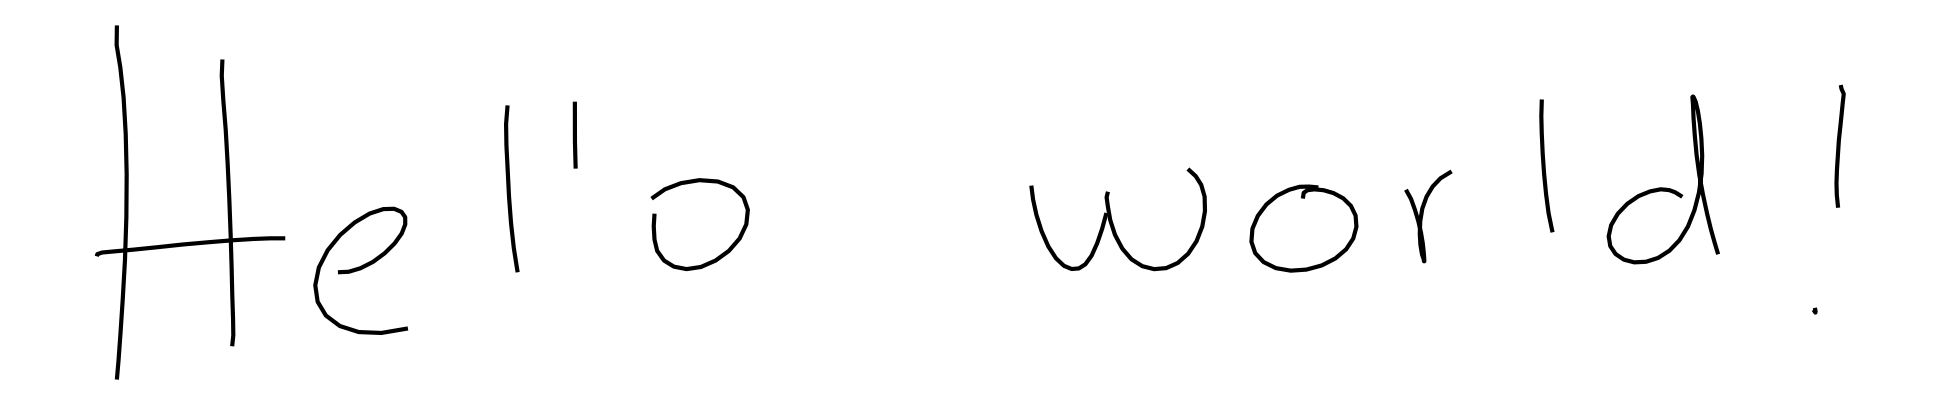

Saved plot to ./logs/synthesis_seq_epoch107.png

Epoch 108/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -839.5550 | Valid Loss: -821.5465
New best model found at epoch 108! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 234
Input seq:  Hello world!  
Length of input sequence:  14


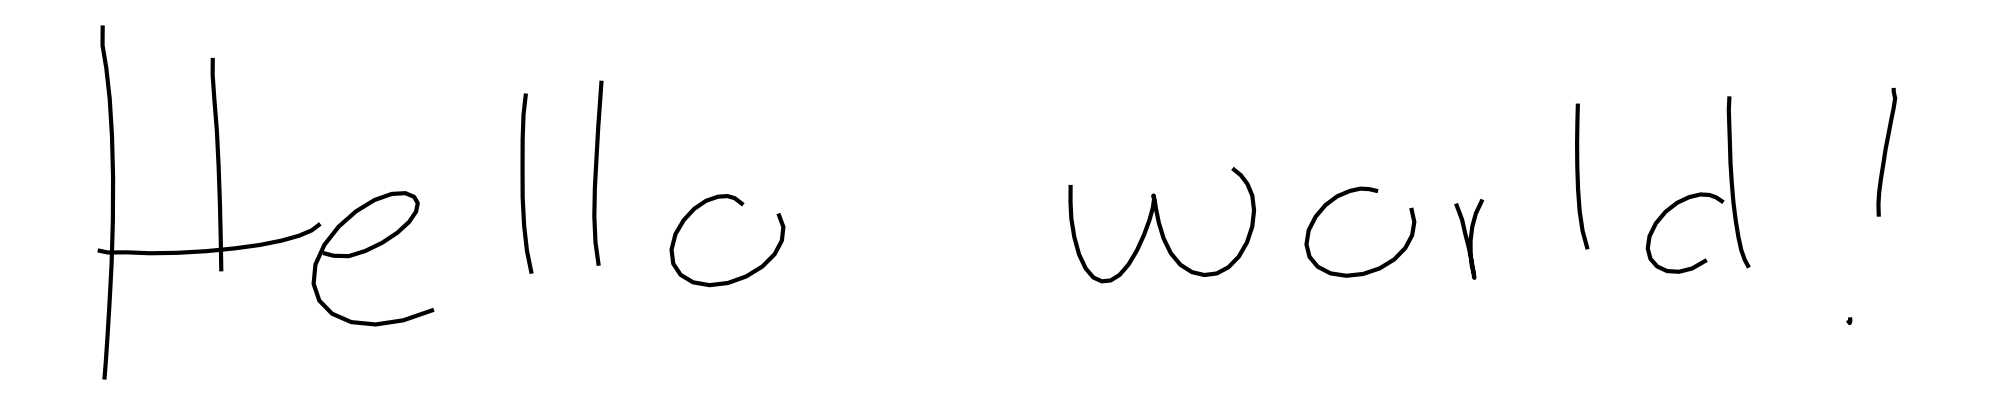

Saved plot to ./logs/synthesis_seq_epoch108.png

Epoch 109/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -840.9166 | Valid Loss: -823.1817
New best model found at epoch 109! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 633
Input seq:  Hello world!  
Length of input sequence:  14


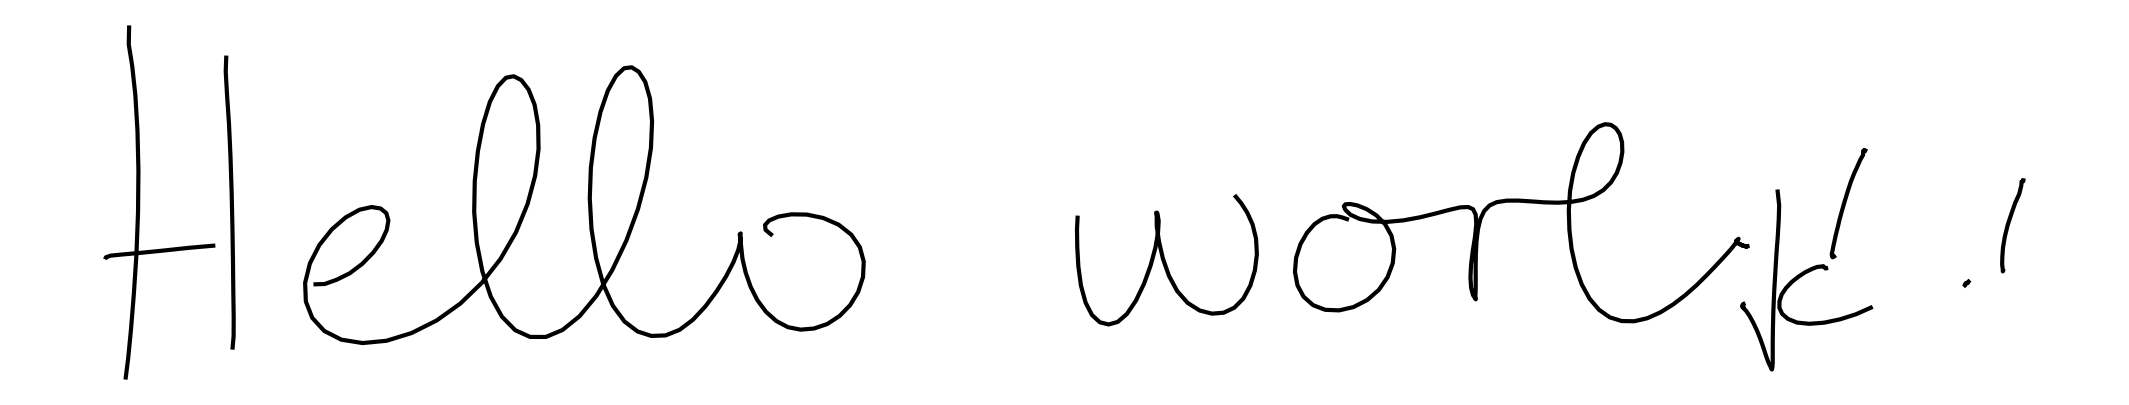

Saved plot to ./logs/synthesis_seq_epoch109.png

Epoch 110/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -841.7303 | Valid Loss: -823.6537
New best model found at epoch 110! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 248
Input seq:  Hello world!  
Length of input sequence:  14


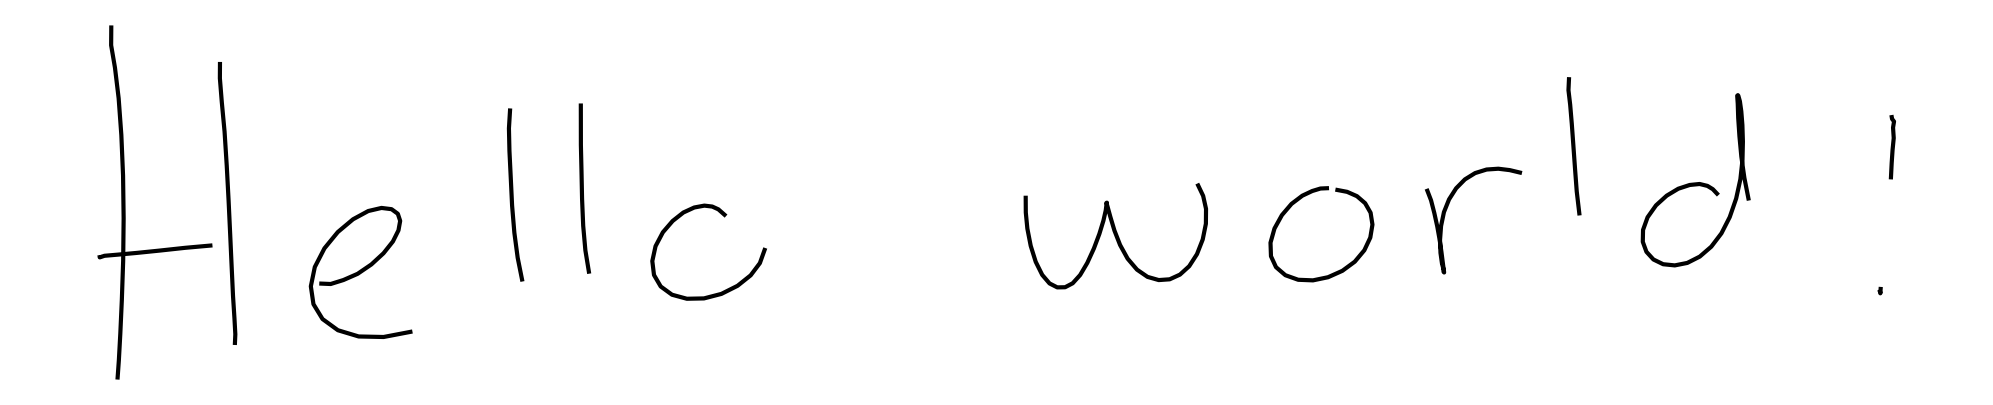

Saved plot to ./logs/synthesis_seq_epoch110.png

Epoch 111/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -842.9597 | Valid Loss: -824.9255
New best model found at epoch 111! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 236
Input seq:  Hello world!  
Length of input sequence:  14


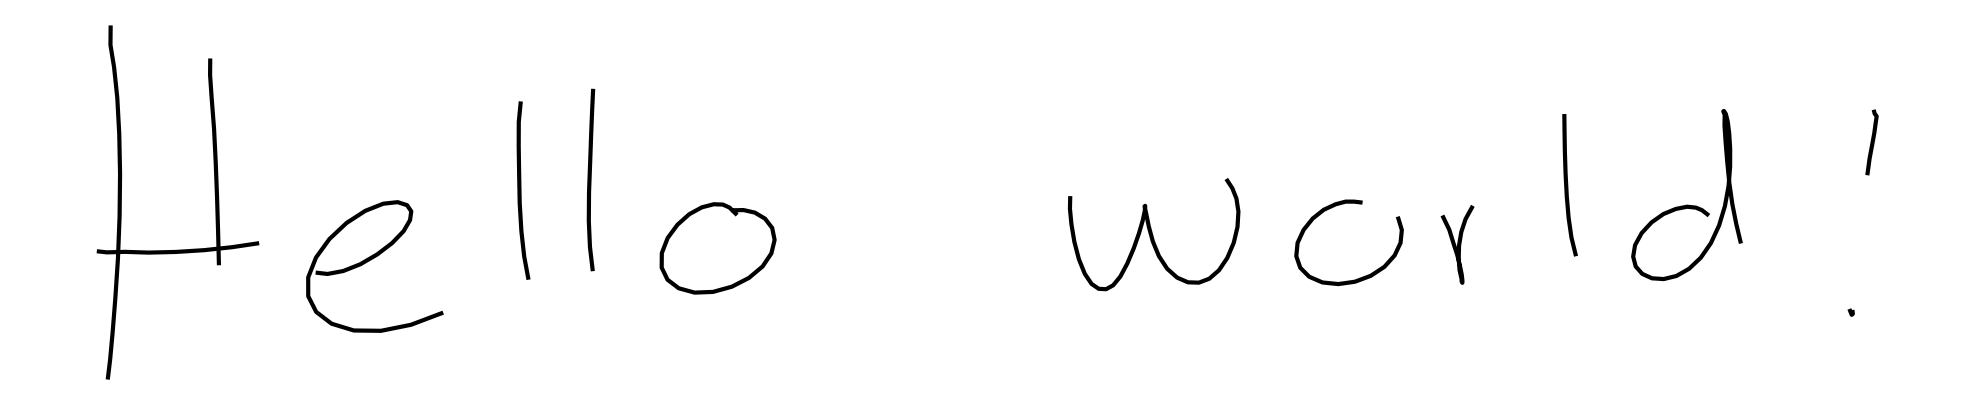

Saved plot to ./logs/synthesis_seq_epoch111.png

Epoch 112/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -844.1837 | Valid Loss: -825.8862
New best model found at epoch 112! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 273
Input seq:  Hello world!  
Length of input sequence:  14


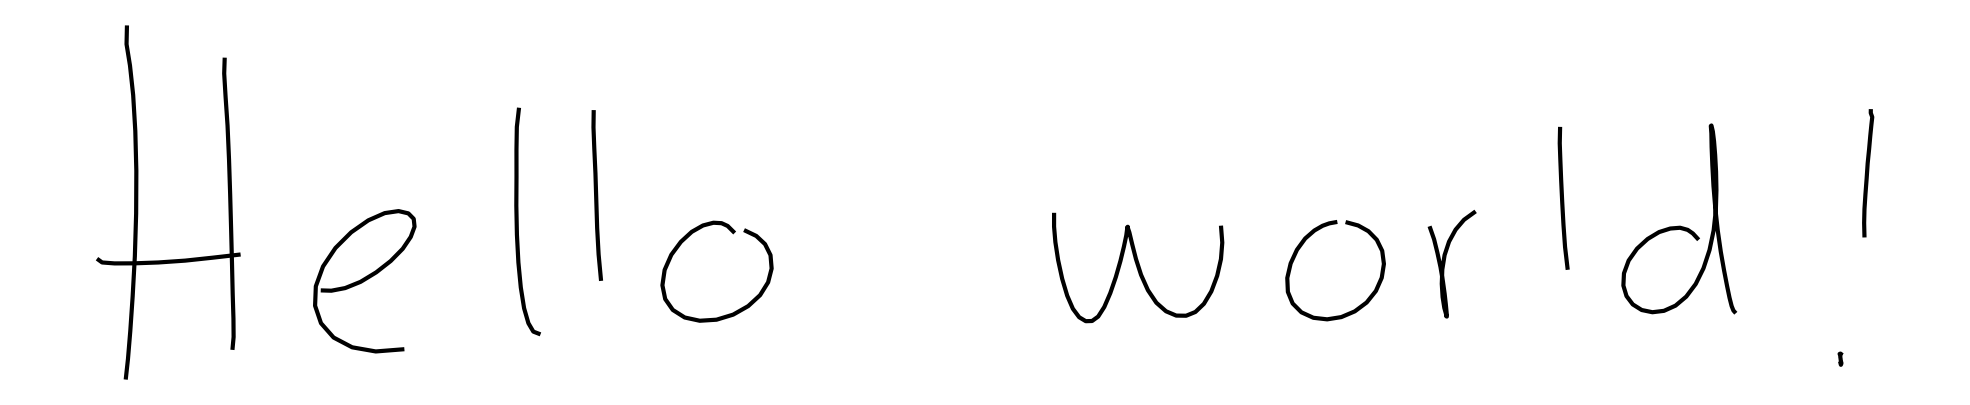

Saved plot to ./logs/synthesis_seq_epoch112.png

Epoch 113/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -845.2310 | Valid Loss: -826.9275
New best model found at epoch 113! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 257
Input seq:  Hello world!  
Length of input sequence:  14


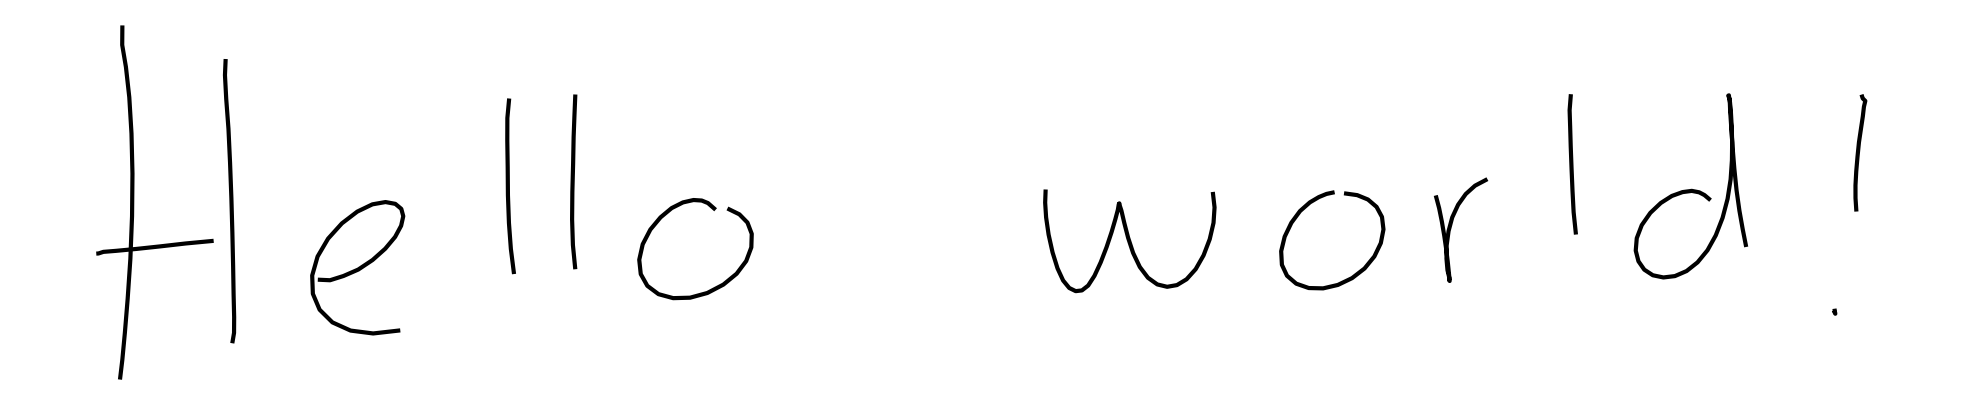

Saved plot to ./logs/synthesis_seq_epoch113.png

Epoch 114/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -846.2507 | Valid Loss: -828.1597
New best model found at epoch 114! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 277
Input seq:  Hello world!  
Length of input sequence:  14


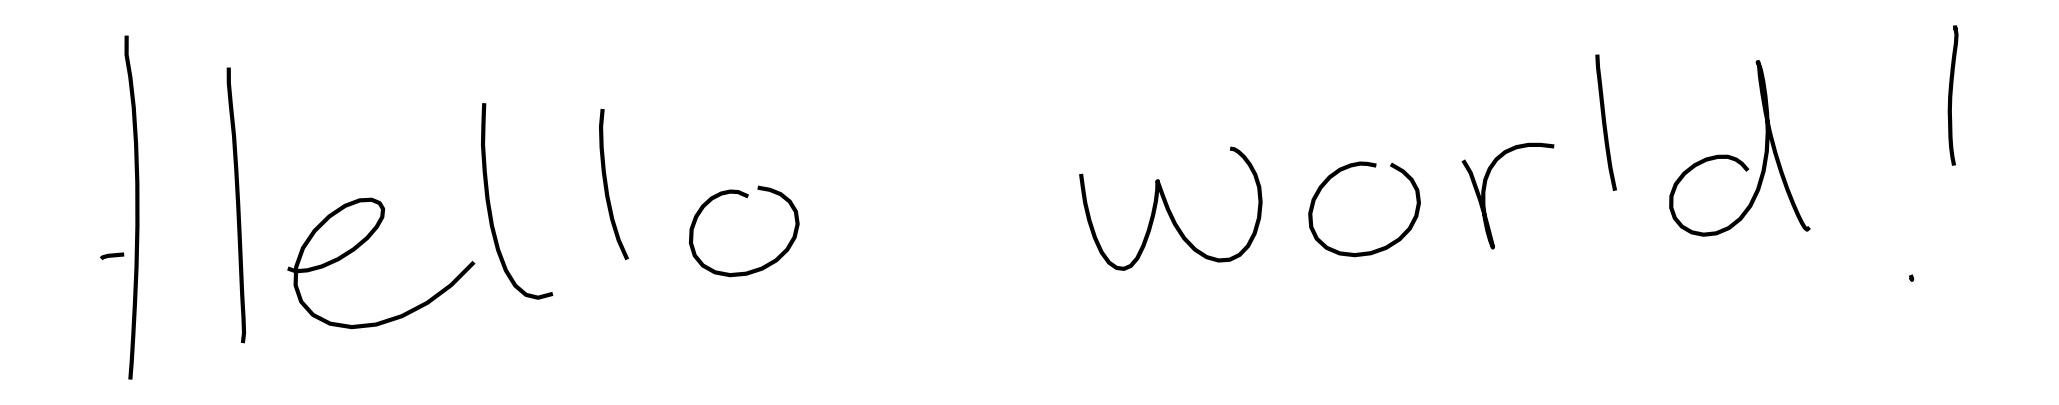

Saved plot to ./logs/synthesis_seq_epoch114.png

Epoch 115/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -847.2425 | Valid Loss: -828.9204
New best model found at epoch 115! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 265
Input seq:  Hello world!  
Length of input sequence:  14


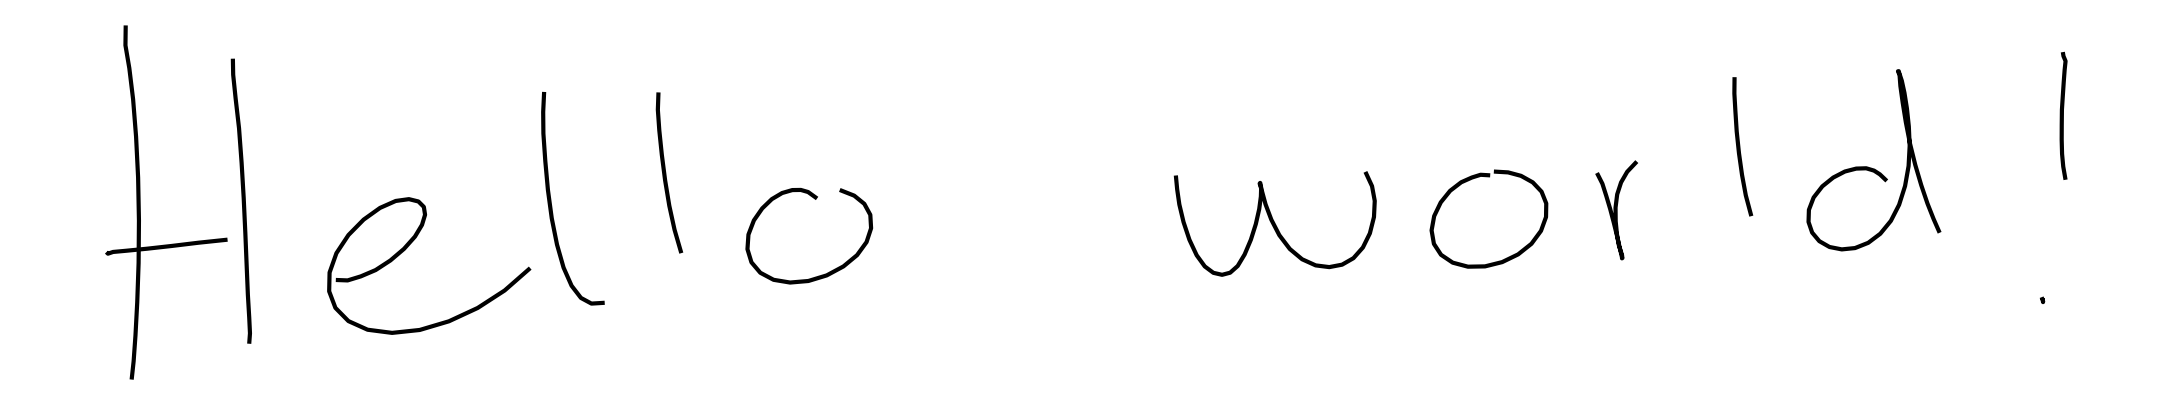

Saved plot to ./logs/synthesis_seq_epoch115.png

Epoch 116/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -848.3702 | Valid Loss: -829.7185
New best model found at epoch 116! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 265
Input seq:  Hello world!  
Length of input sequence:  14


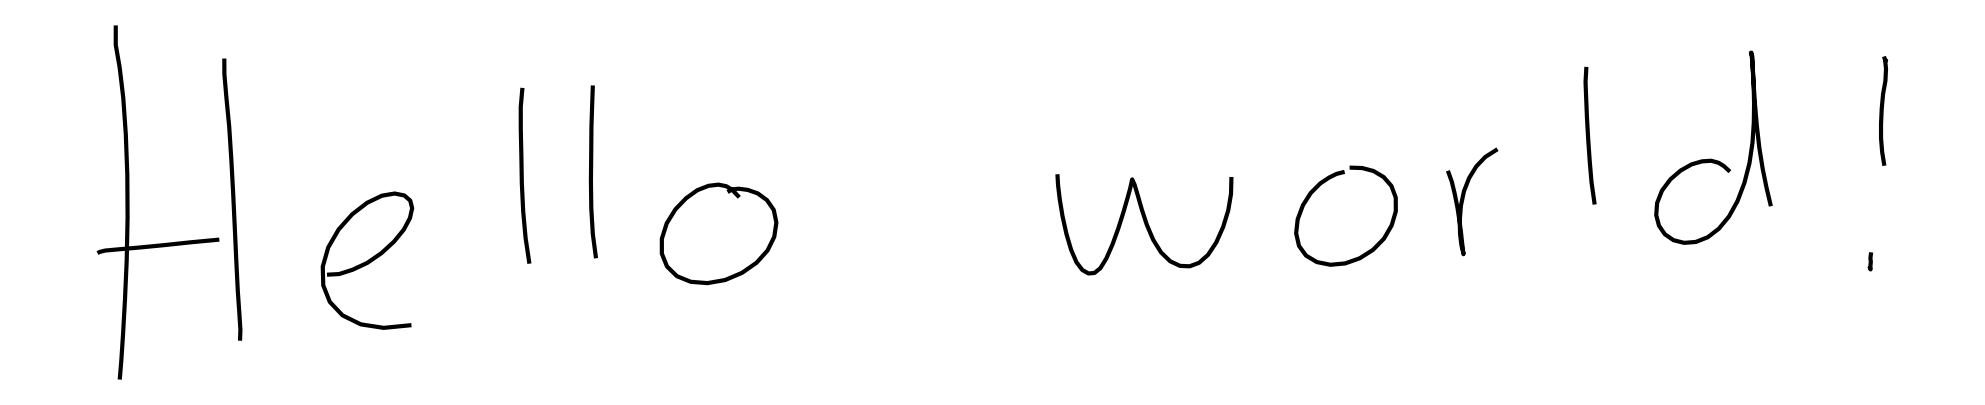

Saved plot to ./logs/synthesis_seq_epoch116.png

Epoch 117/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -849.1734 | Valid Loss: -830.3486
New best model found at epoch 117! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 298
Input seq:  Hello world!  
Length of input sequence:  14


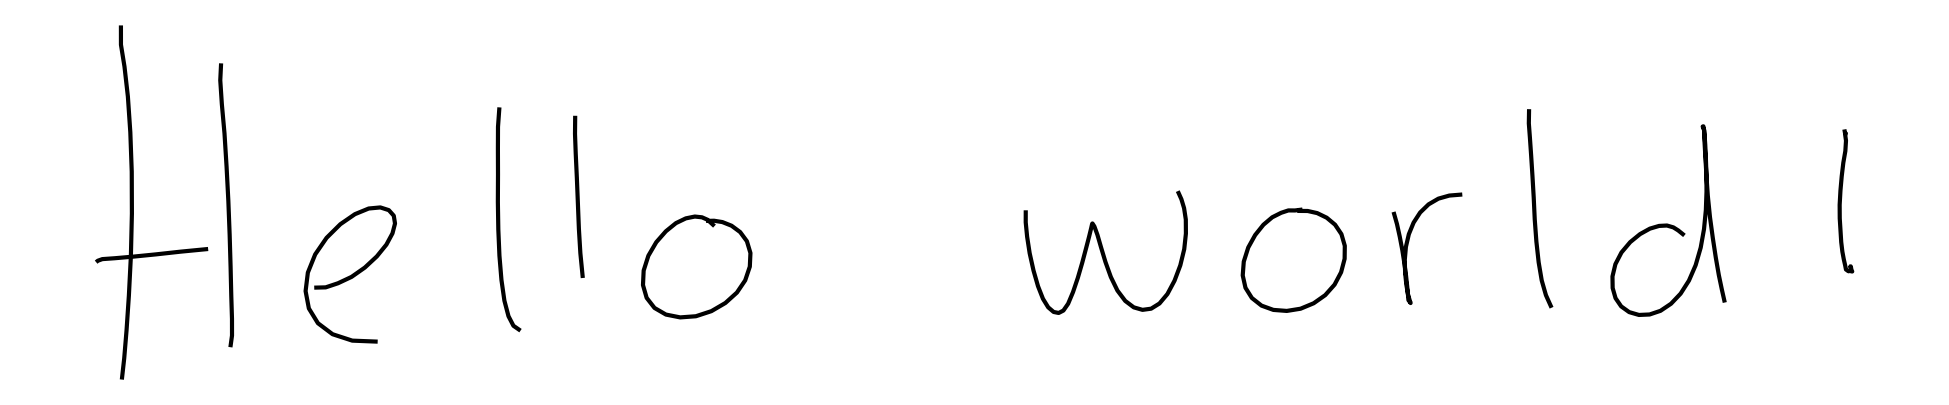

Saved plot to ./logs/synthesis_seq_epoch117.png

Epoch 118/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -850.0901 | Valid Loss: -831.6952
New best model found at epoch 118! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 263
Input seq:  Hello world!  
Length of input sequence:  14


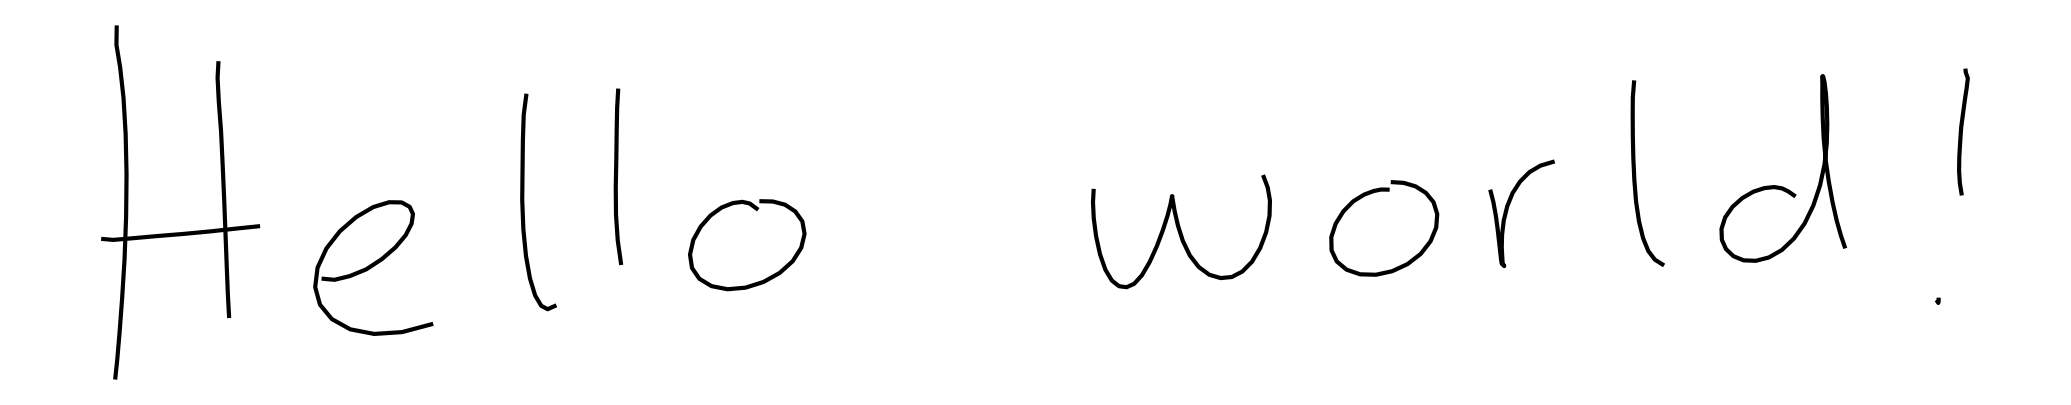

Saved plot to ./logs/synthesis_seq_epoch118.png

Epoch 119/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -850.7508 | Valid Loss: -831.6560

Epoch 120/120


Training:   0%|          | 0/85 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: -851.6123 | Valid Loss: -833.0950
New best model found at epoch 120! Saving...
Vocab size:  77
Hello world!  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 299
Input seq:  Hello world!  
Length of input sequence:  14


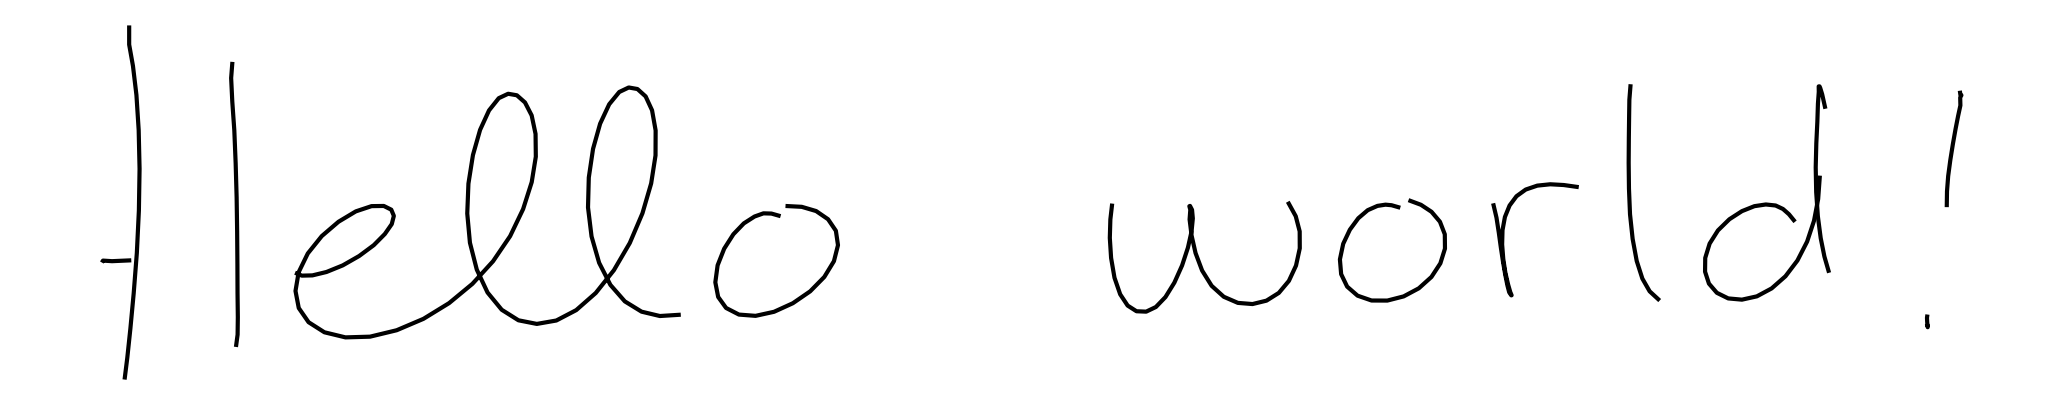

Saved plot to ./logs/synthesis_seq_epoch120.png


In [14]:
# ---- Hyperparameters ----
hidden_size = 400
n_layers = 3
batch_size = 64
n_epochs = 120
step_size = 100
lr = 0.001
patience = 15
data_path = './data/'
save_path = './logs/'
seed = 212
text_req = True
data_aug = False
debug = False

# ---- Setup paths ----
model_checkpoint_path = os.path.join(save_path, 'best_model_synthesis.pt')
checkpoint_path = os.path.join(save_path, 'checkpoint_synthesis.pt')

if not os.path.exists(save_path):
    os.makedirs(save_path)

# ---- Fix random seed ----
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- Load Data ----
train_dataset = HandwritingDataset(data_path, split="train", text_req=text_req, debug=debug, data_aug=data_aug)
valid_dataset = HandwritingDataset(data_path, split="valid", text_req=text_req, debug=debug, data_aug=data_aug)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# ---- Initialize Model ----
model = HandWritingSynthesisNet(hidden_size=hidden_size, n_layers=n_layers, output_size=121, window_size=train_dataset.vocab_size)
model = model.to(device)

# ---- Optimizer and Scheduler ----
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=0.1)

# ---- Load Checkpoint if Exists ----
start_epoch = 0
best_loss = math.inf

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    print(f"Resuming from epoch {start_epoch}, best loss so far: {best_loss:.4f}")

# ---- Training and Validation ----
train_losses = []
valid_losses = []
early_stop_counter = 0

for epoch in range(start_epoch, n_epochs):
    print(f"\nEpoch {epoch+1}/{n_epochs}")

    # ---- Train ----
    model.train()
    train_loss = 0.0
    train_bar = tqdm(train_loader, desc="Training", leave=False)
    for mini_batch in train_bar:
        inputs, targets, mask, text, text_mask = mini_batch

        inputs = inputs.to(device)
        targets = targets.to(device)
        mask = mask.to(device)
        text = text.to(device)
        text_mask = text_mask.to(device)

        batch_size_actual = inputs.shape[0]

        optimizer.zero_grad()

        initial_hidden, window_vector, kappa = model.init_hidden(batch_size_actual, device)
        y_hat, _, _, _ = model.forward(inputs, text, text_mask, initial_hidden, window_vector, kappa)

        loss = compute_nll_loss(targets, y_hat, mask)

        y_hat.register_hook(lambda grad: torch.clamp(grad, -100, 100))
        loss.backward()

        # Clip Gradients
        nn.utils.clip_grad_value_(model.lstm_1.parameters(), 10)
        nn.utils.clip_grad_value_(model.lstm_2.parameters(), 10)
        nn.utils.clip_grad_value_(model.lstm_3.parameters(), 10)
        nn.utils.clip_grad_value_(model.window_layer.parameters(), 10)

        optimizer.step()
        train_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        valid_bar = tqdm(valid_loader, desc="Validating", leave=False)
        for mini_batch in valid_bar:
            inputs, targets, mask, text, text_mask = mini_batch

            inputs = inputs.to(device)
            targets = targets.to(device)
            mask = mask.to(device)
            text = text.to(device)
            text_mask = text_mask.to(device)

            batch_size_actual = inputs.shape[0]

            initial_hidden, window_vector, kappa = model.init_hidden(batch_size_actual, device)
            y_hat, _, _, _ = model.forward(inputs, text, text_mask, initial_hidden, window_vector, kappa)

            loss = compute_nll_loss(targets, y_hat, mask)
            valid_loss += loss.item()

            valid_bar.set_postfix(loss=loss.item())

    valid_loss /= len(valid_loader.dataset)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

    # ---- Learning Rate Step ----
    if step_size != -1:
        scheduler.step()

    # ---- Check for Best Model ----
    if valid_loss < best_loss:
        best_loss = valid_loss
        early_stop_counter = 0
        print(f"New best model found at epoch {epoch+1}! Saving...")

        torch.save(model.state_dict(), model_checkpoint_path)

        # Generate and save output
        gen_seq, phi = generate_conditional_sequence(
            model_checkpoint_path, "Hello world!", device,
            train_loader.dataset.char_to_id, train_loader.dataset.idx_to_char,
            bias=10.0, prime=False, prime_seq=None, real_text=None, is_map=True,
        )

        plt.imshow(phi, cmap="viridis", aspect="auto")
        plt.colorbar()
        plt.xlabel("Time steps")
        plt.yticks(np.arange(len(list("Hello world!  "))), list("Hello world!  "), rotation="horizontal")
        plt.margins(0.2)
        plt.subplots_adjust(bottom=0.15)
        plt.savefig(os.path.join(save_path, f"heat_map_epoch{epoch+1}.png"))
        plt.close()

        gen_seq = data_denormalization(Global.train_mean, Global.train_std, gen_seq)
        plot_stroke(gen_seq[0], save_name=os.path.join(save_path, f"synthesis_seq_epoch{epoch+1}.png"), display=True)
    else:
        early_stop_counter += 1

    # ---- Save checkpoint ----
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_loss': best_loss
    }, checkpoint_path)

    # ---- Early Stopping ----
    if early_stop_counter > patience:
        print(f"Early stopping at epoch {epoch+1}. Best epoch was {epoch+1-patience}.")
        break


# Result Samples

Vocab size:  77
Artificial Intelligence Course Project  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 1000
Input seq:  Artificial Intelligence Course Project  
Length of input sequence:  40


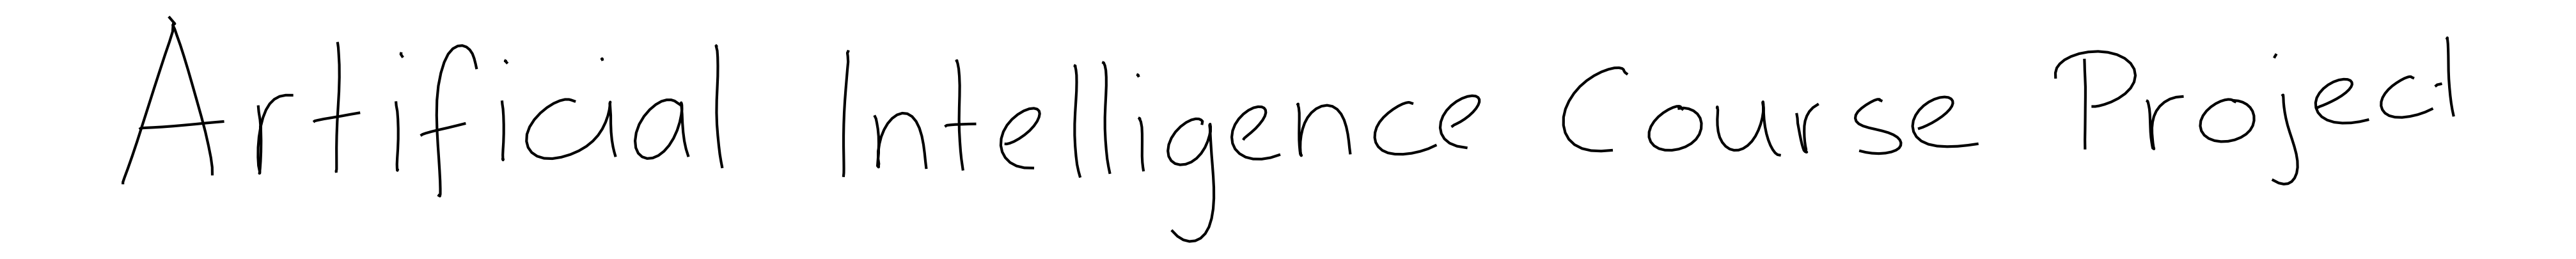

Saved plot to results\gen_seq_0.png


In [18]:
model = "synthesis" 
model_path = Path("./logs/best_model_synthesis.pt")
save_path = Path("./results/")
seq_len = 400
batch_size = 1
bias = 10.0
char_seq = "Artificial Intelligence Course Project"
text_req = False
prime = False
is_map = False
seed = None
data_path = "./data/"
file_path = None  # or "./app/"

save_path.mkdir(parents=True, exist_ok=True)

if seed:
    torch.manual_seed(seed)
    np.random.seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Dataset loading
train_dataset = HandwritingDataset(data_path, split="train", text_req=text_req)

if prime and file_path:
    style = np.load(
        os.path.join(file_path, "style.npy"), allow_pickle=True, encoding="bytes"
    ).astype(np.float32)
    with open(os.path.join(file_path, "inpText.txt")) as file:
        texts = file.read().splitlines()
    real_text = texts[0]
    plot_stroke(style, save_name=save_path / "style.png")
    plt.show()
    mean, std, _ = data_normalization(style)
    style = torch.from_numpy(style).unsqueeze(0).to(device)
    ytext = real_text + " " + char_seq + "  "
elif prime:
    strokes = np.load(
        os.path.join(data_path, "strokes.npy"), allow_pickle=True, encoding="bytes"
    )
    with open(os.path.join(data_path, "sentences.txt")) as file:
        texts = file.read().splitlines()
    idx = np.random.randint(0, len(strokes))
    print("Prime style index: ", idx)
    real_text = texts[idx]
    style = strokes[idx]
    plot_stroke(style, save_name=save_path / f"style_{idx}.png")
    plt.show()
    mean, std, _ = data_normalization(style)
    style = np.array([style for _ in range(batch_size)])
    style = torch.from_numpy(style).to(device)
    ytext = real_text + " " + char_seq + "  "
else:
    idx = -1
    real_text = ""
    style = None
    ytext = char_seq + "  "


gen_seq, phi = generate_conditional_sequence(
    model_path,
    char_seq,
    device,
    train_dataset.char_to_id,
    train_dataset.idx_to_char,
    bias,
    prime,
    style,
    real_text,
    is_map,
    batch_size,
)
if is_map:
    plt.figure(figsize=(12, 6))
    plt.imshow(phi, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.xlabel("time steps")
    plt.yticks(np.arange(phi.shape[0]), list(ytext), rotation="horizontal")
    plt.margins(0.2)
    plt.subplots_adjust(bottom=0.15)
    plt.title("Attention Heatmap")
    plt.savefig(save_path / "heat_map.png")
    plt.show()

gen_seq = data_denormalization(Global.train_mean, Global.train_std, gen_seq)

for i in range(batch_size):
    plot_stroke(
        gen_seq[i], save_name=save_path / f"gen_seq_{i}.png",display = True
    )
    plt.show()

Saved animation to stroke_0.gif


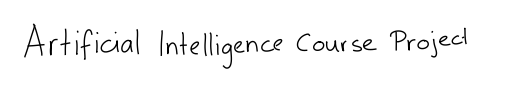

In [19]:
def animate_stroke(stroke, save_name=None):
    x = np.cumsum(stroke[:, 1])
    y = np.cumsum(stroke[:, 2])
    pos = np.stack([x, y], axis=1)

    cuts = np.where(stroke[:, 0] == 1)[0]
    segments = []
    start = 0
    for cut in cuts:
        segments.append(pos[start:cut])
        start = cut + 1
    if start < len(pos):
        segments.append(pos[start:])

    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_xlim(pos[:, 0].min() - 10, pos[:, 0].max() + 10)
    ax.set_ylim(pos[:, 1].min() - 10, pos[:, 1].max() + 10)

    lines = [ax.plot([], [], 'k-', linewidth=1.0)[0] for _ in segments]

    segment_lengths = [len(seg) for seg in segments]
    start_frames = np.cumsum([0] + segment_lengths[:-1])
    end_frames = np.cumsum(segment_lengths)
    total_frames = sum(segment_lengths)

    def ease_out(t):
        return 1 - (1 - t) ** 2 

    def update(frame):
        for i, (start_f, end_f) in enumerate(zip(start_frames, end_frames)):
            if frame < start_f:
                lines[i].set_data([], [])
            elif frame >= end_f:
                lines[i].set_data(segments[i][:, 0], segments[i][:, 1])
            else:
                idx_float = frame - start_f
                length = len(segments[i])
                t = idx_float / (end_f - start_f)
                eased = ease_out(t)
                idx = max(1, int(eased * length))
                lines[i].set_data(segments[i][:idx, 0], segments[i][:idx, 1])
        return lines

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=total_frames,
        interval=30,  # Faster animation
        blit=True
    )

    if save_name:
        ani.save(save_name, writer='pillow')
        print(f"Saved animation to {save_name}")

    return ani, fig


for i in range(batch_size):
    save_name = f'stroke_{i}.gif'  
    ani, fig = animate_stroke(gen_seq[i], save_name=save_name)
    plt.show() 
    plt.close(fig)  

Prime style index:  5


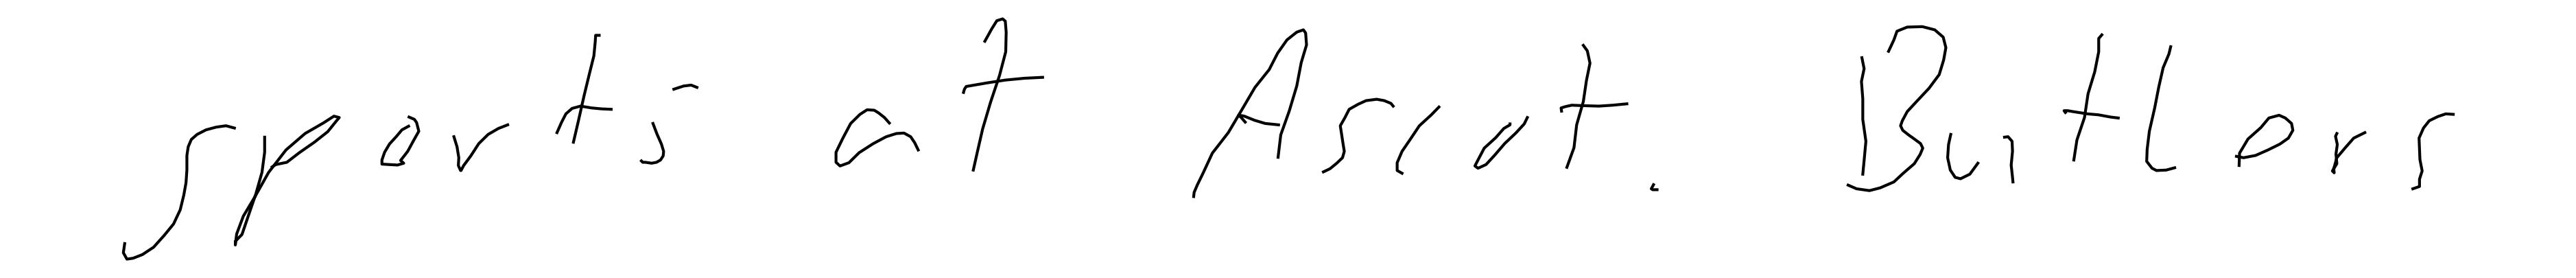

Priming text:  sports at Ascot. Butlers
Priming sequence size:  torch.Size([1, 377, 3])
Vocab size:  77
artificial Intelligence project  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 551
Input seq:  artificial Intelligence project  
Length of input sequence:  33


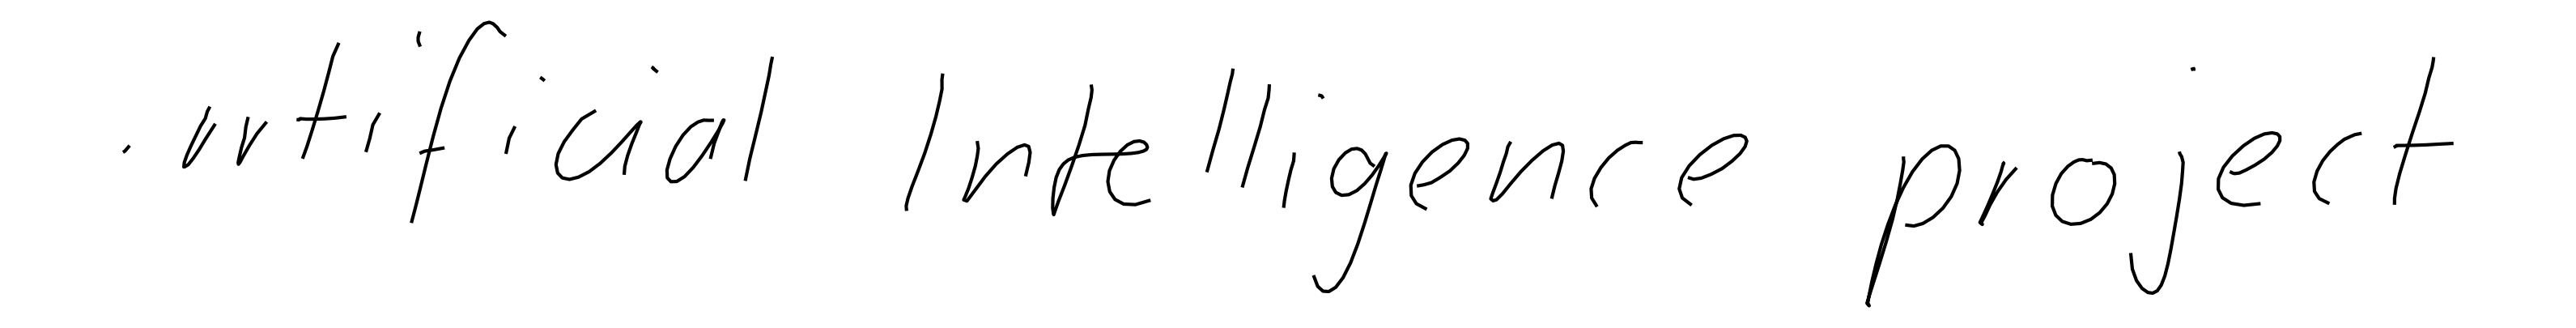

In [113]:
prime = True
bias = 6.
char_seq = "artificial Intelligence project"
is_map = False

strokes = np.load(data_path + 'strokes.npy',
                          allow_pickle=True, encoding='bytes')
with open(data_path + 'sentences.txt') as file:
    texts = file.read().splitlines()
    
idx = 5
print("Prime style index: ", idx)
real_text = texts[idx]
style = strokes[idx] 
# plot the sequence
plot_stroke(style)
print("Priming text: ", real_text)

mean, std, style = data_normalization(style)
style = torch.from_numpy(style).unsqueeze(0).to(device)

# style = valid_offset_normalization(Global.train_mean, Global.train_std, style[None,:,:])
# style = torch.from_numpy(style).to(device)
print("Priming sequence size: ", style.shape)

ytext = real_text + ' ' + char_seq + "  " 

gen_seq, phi = generate_conditional_sequence(
            model_path, char_seq, device, train_dataset.char_to_id,
            train_dataset.idx_to_char, bias, prime, style, real_text, is_map)


gen_seq = data_denormalization(Global.train_mean, Global.train_std, gen_seq)
# plot the sequence
plot_stroke(gen_seq[0])

# Metrics

In [143]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
data_path = './data/'
model_checkpoint_path = './logs/best_model_synthesis.pt'
train_dataset = HandwritingDataset(data_path, split="train", text_req=True, debug=False)
print(f"Vocabulary size: {train_dataset.vocab_size}")
if os.path.exists(model_checkpoint_path):
    print(f"Model file found at {model_checkpoint_path}")

Using device: cuda:0
Vocabulary size: 77
Model file found at ./logs/best_model_synthesis.pt


Vocab size:  77
Hello World  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 265
Input seq:  Hello World  
Length of input sequence:  13
Saved plot to temp.png


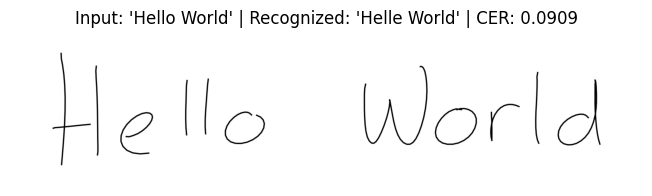

Input: 'Hello World' | Recognized: 'Helle World' | CER: 0.0909
Vocab size:  77
This is a test  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 308
Input seq:  This is a test  
Length of input sequence:  16
Saved plot to temp.png


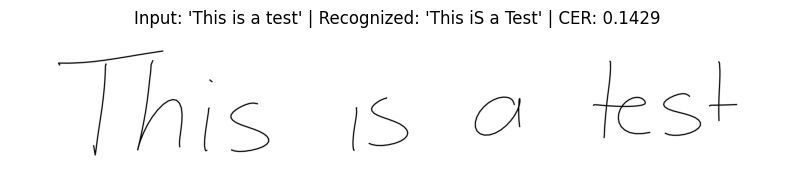

Input: 'This is a test' | Recognized: 'This iS a Test' | CER: 0.1429
Vocab size:  77
Handwriting  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 352
Input seq:  Handwriting  
Length of input sequence:  13
Saved plot to temp.png


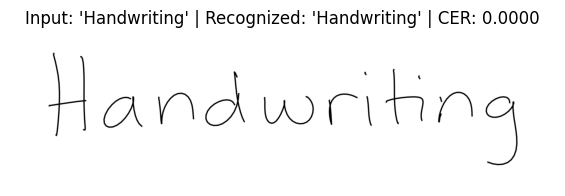

Input: 'Handwriting' | Recognized: 'Handwriting' | CER: 0.0000
Vocab size:  77
Hi there  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 165
Input seq:  Hi there  
Length of input sequence:  10
Saved plot to temp.png


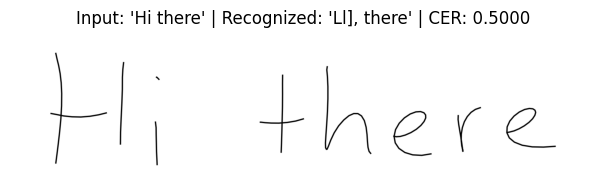

Input: 'Hi there' | Recognized: 'Ll], there' | CER: 0.5000
Vocab size:  77
good Day  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 303
Input seq:  good Day  
Length of input sequence:  10
Saved plot to temp.png


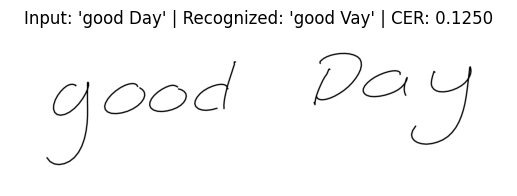

Input: 'good Day' | Recognized: 'good Vay' | CER: 0.1250


In [152]:
def calculate_cer(reference_text, recognized_text):
    return jiwer.cer(reference_text, recognized_text)

def evaluate_cer(input_text, model_path, device, char_to_id, idx_to_char, save_path="temp.png"):
    gen_seq, _ = generate_conditional_sequence(
        model_path, input_text, device, char_to_id, idx_to_char,
        bias=8.0, prime=False, prime_seq=None, real_text=None, is_map=False
    )
    
    gen_seq = data_denormalization(Global.train_mean, Global.train_std, gen_seq)
    plot_stroke(gen_seq[0], save_name=save_path, display=False)
    
    img = PIL.Image.open(save_path)
    recognized_text = pytesseract.image_to_string(img, config='--psm 7')  # Single line mode
    recognized_text = recognized_text.strip()

    cer = calculate_cer(input_text, recognized_text)
    
    plt.figure(figsize=(10, 2))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Input: '{input_text}' | Recognized: '{recognized_text}' | CER: {cer:.4f}")
    plt.show()
    
    os.remove(save_path)
    
    return recognized_text, cer

test_texts = [
    "Hello World",      
    "This is a test",    
    "Handwriting",      
    "Hi there",        
    "good Day",
]
for text in test_texts:
    recognized_text, cer = evaluate_cer(
        text, model_checkpoint_path, device, 
        train_dataset.char_to_id, train_dataset.idx_to_char
    )
    print(f"Input: '{text}' | Recognized: '{recognized_text}' | CER: {cer:.4f}")

In [64]:
def calculate_cer(model_path, data_path, device='cpu', batch_size=1, bias=10.0):
    dataset = HandwritingDataset(data_path, split='valid', text_req=True)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    ground_truths = []
    predictions = []

    with torch.no_grad():
        for mini_batch in tqdm(data_loader, desc="Calculating CER"):
            inputs, _, _, text, text_mask = mini_batch
            inputs = inputs.to(device)
            text = text.to(device)
            text_mask = text_mask.to(device)

            char_seq = "".join(dataset.idx_to_char(text[0].cpu().numpy())).strip()

            gen_seq, _ = generate_conditional_sequence(
                model_path, char_seq, device, dataset.char_to_id, dataset.idx_to_char,
                bias=bias, prime=False, prime_seq=None, real_text=None, is_map=False
            )

            gen_seq = data_denormalization(Global.train_mean, Global.train_std, gen_seq)
            plot_stroke(gen_seq[0], save_name="temp.png", display=False)

            img = Image.open("temp.png")
            pred_text = pytesseract.image_to_string(img, config='--psm 7').strip()
            os.remove("temp.png")

            ground_truths.append(char_seq)
            predictions.append(pred_text)

    cer = jiwer.cer(ground_truths, predictions)
    print(f"Character Error Rate (CER): {cer:.4f}")
    return cer

model_path = "./logs/best_model_synthesis.pt"
data_path = "./data/"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cer = calculate_cer(model_path, data_path, device=device)

Calculating CER:   0%|                                                                         | 0/600 [00:00<?, ?it/s]

batch_size: 1
EOS: True
seq_len: 1270
Saved plot to temp.png


Calculating CER:   0%|                                                                 | 1/600 [00:03<37:50,  3.79s/it]

batch_size: 1
EOS: True
seq_len: 828
Saved plot to temp.png


Calculating CER:   0%|▏                                                                | 2/600 [00:06<29:42,  2.98s/it]

...

batch_size: 1
EOS: True
seq_len: 814
Saved plot to temp.png


Calculating CER: 100%|██████████████████████████████████████████████████████████████▉| 599/600 [27:56<00:02,  2.19s/it]

batch_size: 1
EOS: False
seq_len: 2000
Saved plot to temp.png


Calculating CER: 100%|███████████████████████████████████████████████████████████████| 600/600 [28:02<00:00,  2.80s/it]

Character Error Rate (CER): 0.4338


In [34]:
import PIL.Image


Computing similarities:   0%|          | 0/600 [00:00<?, ?it/s]

Vocab size:  77
it open, and waved the trotting detail  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 853
Input seq:  it open, and waved the trotting detail  
Length of input sequence:  40
Vocab size:  77
sion of Germany. Britain could not be a  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 1158
Input seq:  sion of Germany. Britain could not be a  
Length of input sequence:  41
Vocab size:  77
He relived the scene in the  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 596
Input seq:  He relived the scene in the  
Length of input sequence:  29
Vocab size:  77
stitch that you learn. When you  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 974
Input seq:  stitch that you learn. When you  
Length of input sequence:  33
Vocab size:  77
mot mower). We welcome  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 677
Input seq:  mot mower). We welcome  
Length of input sequence:  24
Vocab size:  77
said gently: " I hope everything  
Generatin

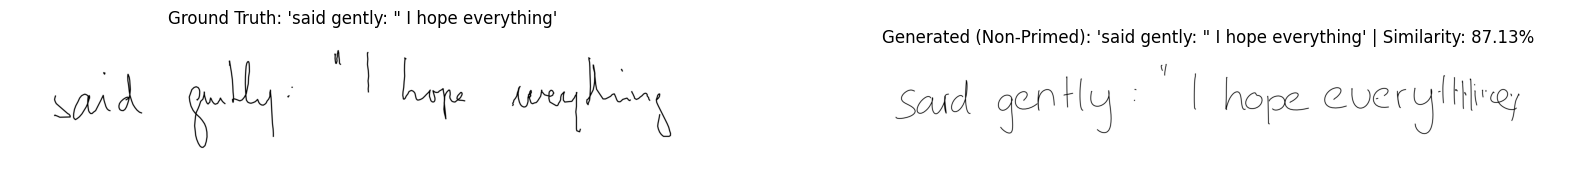

Vocab size:  77
distinct in respect of place but not of  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 906
Input seq:  distinct in respect of place but not of  
Length of input sequence:  41
Vocab size:  77
like cold needles, sprang out on  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 672
Input seq:  like cold needles, sprang out on  
Length of input sequence:  34
Vocab size:  77
objected. "If you want this lot on in  
Generating sequence....
batch_size: 1
EOS: False
seq_len: 2000
Input seq:  objected. "If you want this lot on in  
Length of input sequence:  39
Vocab size:  77
representative basis but rather of energetic  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 1193
Input seq:  representative basis but rather of energetic  
Length of input sequence:  46
Vocab size:  77
low harsh voice. Don't kid yourself  
Generating sequence....
batch_size: 1
EOS: True
seq_len: 1011
Input seq:  low harsh voice. Don't kid yourself  
Length of input sequence:  

In [35]:

def plot_strokes_in_memory(stroke, save_name=None, display=True, in_memory=False):
    f, ax = plt.subplots()
    x = np.cumsum(stroke[:, 1])
    y = np.cumsum(stroke[:, 2])
    size_x = x.max() - x.min() + 1.0
    size_y = y.max() - y.min() + 1.0
    f.set_size_inches(5.0 * size_x / size_y, 5.0)
    cuts = np.where(stroke[:, 0] == 1)[0]
    start = 0
    for cut_value in cuts:
        ax.plot(x[start:cut_value], y[start:cut_value], "k-", linewidth=3)
        start = cut_value + 1
    ax.axis("off")
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

    if in_memory:
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches="tight", pad_inches=0.5)
        plt.close()
        buf.seek(0)
        return PIL.Image.open(buf)

    
    if display:
        plt.show()
    
    if save_name:
        try:
            plt.savefig(save_name, bbox_inches="tight", pad_inches=0.5)
            print(f"Saved plot to {save_name}")
        except Exception as e:
            print(f"Error saving image to {save_name}: {e}")
    
    plt.close()

def dtw_distance(seq1, seq2):
    points1 = seq1[:, 1:3]  # [N, 2]
    points2 = seq2[:, 1:3]  # [M, 2]
    
    distance, _ = fastdtw(points1, points2, dist=euclidean)
    return distance / min(len(points1), len(points2))  # Normalize by sequence length

def distance_to_similarity(distance, scale):
    normalized = max(0, min(1, 1 - (distance / scale)))
    return normalized * 100  # As percentage

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
data_path = './data/'
model_checkpoint_path = './logs/best_model_synthesis.pt'

valid_dataset = HandwritingDataset(data_path, split="valid", text_req=True, debug=False)

similarities = []
example_idx = 5  

if example_idx >= len(valid_dataset):
    raise IndexError(f"Index {example_idx} is out of range for validation dataset (size: {len(valid_dataset)})")

for idx in tqdm(range(len(valid_dataset)), desc="Computing similarities"):
    ground_seq, _, _, ground_text, _ = valid_dataset[idx]
    ground_truth_text = "".join(valid_dataset.idx_to_char(ground_text.cpu().numpy())).strip()
    ground_truth_strokes = ground_seq.cpu().numpy()  # [seq_len, 3]

    ground_truth_strokes = data_denormalization(Global.train_mean, Global.train_std, ground_truth_strokes[np.newaxis, :])[0]

    generated_seq, _ = generate_conditional_sequence(
        model_checkpoint_path, ground_truth_text, device, valid_dataset.char_to_id, valid_dataset.idx_to_char,
        bias=8.0, prime=False, prime_seq=None, real_text=None, is_map=False
    )
    generated_seq = data_denormalization(Global.train_mean, Global.train_std, generated_seq)[0]  # [seq_len, 3]

    distance = dtw_distance(generated_seq, ground_truth_strokes)

    coords = np.concatenate([generated_seq[:, 1:3], ground_truth_strokes[:, 1:3]], axis=0)
    stroke_lengths = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    scale = np.mean(stroke_lengths) * 10  

    similarity = distance_to_similarity(distance, scale)
    similarities.append(similarity)

    if idx == example_idx:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 2))
        plt.sca(ax1)
        img_gt = plot_strokes_in_memory(ground_truth_strokes, in_memory=True)
        ax1.imshow(img_gt)
        ax1.set_title(f"Ground Truth: '{ground_truth_text}'")
        ax1.axis('off')

        plt.sca(ax2)
        img_gen = plot_strokes_in_memory(generated_seq, in_memory=True)
        ax2.imshow(img_gen)
        ax2.set_title(f"Generated (Non-Primed): '{ground_truth_text}' | Similarity: {similarity:.2f}%")
        ax2.axis('off')

        plt.show()

average_similarity = np.mean(similarities)

print(f"Ground Truth Text (Index {example_idx}): '{ground_truth_text}'")
print(f"Similarity at Index {example_idx}: {similarities[example_idx]:.2f}%")
print(f"Average Similarity across validation dataset: {average_similarity:.2f}%")